In [1]:
import numpy as np
import matplotlib.pyplot as plt

## High dimensional centered Gaussian simulation results

In [2]:
# N = 10000
epsilon = 0.1
scale_vals = np.linspace(0, 20, 201)  # set of chosen x0 norm

In [3]:
# OLD VERSION...

# class ExactFlowNUTS_MultiD_Gaussian:
#     """
#     Exact-flow NUTS tree simulator for the d-dimensional Gaussian target

#         pi(x) = N(0, Sigma),   A = Sigma^{-1}.

#     Hamiltonian:

#         H(x,p) = 1/2 x^T A x + 1/2 p^T p.

#     Exact flow:

#         x(t) = cos(t A^{1/2}) x0
#                + A^{-1/2} sin(t A^{1/2}) p0,

#         p(t) = - A^{1/2} sin(t A^{1/2}) x0
#                + cos(t A^{1/2}) p0.

#     This keeps the Hoffman-Gelman random doubling construction,
#     but replaces leapfrog integration by the exact Gaussian Hamiltonian flow.

#     We record K_star = number of successful completed full-tree doublings
#     before stopping.
#     """

#     def __init__(self, A=None, Sigma=None, epsilon=0.1, rng=None, tol=1e-12):
#         """
#         Parameters
#         ----------
#         A : np.ndarray, shape (d,d)
#             Precision matrix A = Sigma^{-1}. Must be symmetric positive definite.

#         Sigma : np.ndarray, shape (d,d)
#             Covariance matrix. If A is not supplied, A = inv(Sigma).

#         epsilon : float
#             Grid step size.

#         rng : np.random.Generator or None
#             Random number generator.

#         tol : float
#             Numerical tolerance used in U-turn comparisons.
#         """

#         if A is None and Sigma is None:
#             raise ValueError("Please provide either A or Sigma.")

#         if A is not None and Sigma is not None:
#             raise ValueError("Please provide only one of A or Sigma, not both.")

#         if Sigma is not None:
#             Sigma = np.asarray(Sigma, dtype=float)
#             A = np.linalg.inv(Sigma)
#         else:
#             A = np.asarray(A, dtype=float)

#         if A.ndim != 2 or A.shape[0] != A.shape[1]:
#             raise ValueError("A must be a square matrix.")

#         # Symmetrise for numerical safety
#         A = 0.5 * (A + A.T)

#         eigvals, eigvecs = np.linalg.eigh(A)

#         if np.any(eigvals <= 0):
#             raise ValueError("A must be positive definite.")

#         self.A = A
#         self.eigvals = eigvals
#         self.eigvecs = eigvecs
#         self.sqrt_eigvals = np.sqrt(eigvals)

#         self.d = A.shape[0]
#         self.epsilon = epsilon
#         self.rng = np.random.default_rng() if rng is None else rng
#         self.tol = tol

#     # ------------------------------------------------------------
#     # Matrix-function-vector products
#     # ------------------------------------------------------------
#     def _cos_sqrtA_times(self, t, v):
#         """
#         Compute cos(t A^{1/2}) v using the eigendecomposition of A.
#         """
#         Q = self.eigvecs
#         lam_sqrt = self.sqrt_eigvals

#         v_hat = Q.T @ v
#         out_hat = np.cos(t * lam_sqrt) * v_hat

#         return Q @ out_hat

#     def _invsqrtA_sin_sqrtA_times(self, t, v):
#         """
#         Compute A^{-1/2} sin(t A^{1/2}) v.
#         """
#         Q = self.eigvecs
#         lam_sqrt = self.sqrt_eigvals

#         v_hat = Q.T @ v
#         out_hat = (np.sin(t * lam_sqrt) / lam_sqrt) * v_hat

#         return Q @ out_hat

#     def _sqrtA_sin_sqrtA_times(self, t, v):
#         """
#         Compute A^{1/2} sin(t A^{1/2}) v.
#         """
#         Q = self.eigvecs
#         lam_sqrt = self.sqrt_eigvals

#         v_hat = Q.T @ v
#         out_hat = lam_sqrt * np.sin(t * lam_sqrt) * v_hat

#         return Q @ out_hat

#     # ------------------------------------------------------------
#     # Exact Hamiltonian state
#     # ------------------------------------------------------------
#     def state(self, n, x0, p0):
#         """
#         Exact Hamiltonian state at grid index n, i.e. time t = n epsilon.

#         Returns
#         -------
#         x_n : np.ndarray, shape (d,)
#         p_n : np.ndarray, shape (d,)
#         """

#         x0 = np.asarray(x0, dtype=float)
#         p0 = np.asarray(p0, dtype=float)

#         if x0.shape != (self.d,) or p0.shape != (self.d,):
#             raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

#         t = n * self.epsilon

#         x_n = (
#             self._cos_sqrtA_times(t, x0)
#             + self._invsqrtA_sin_sqrtA_times(t, p0)
#         )

#         p_n = (
#             - self._sqrtA_sin_sqrtA_times(t, x0)
#             + self._cos_sqrtA_times(t, p0)
#         )

#         return x_n, p_n

#     # ------------------------------------------------------------
#     # Multidimensional no-U-turn criterion
#     # ------------------------------------------------------------
#     def no_Uturn(self, a, b, x0, p0):
#         """
#         Return True if the block [a,b] passes the multidimensional
#         endpoint no-U-turn test:

#             (x_b - x_a)^T p_a >= 0
#             (x_b - x_a)^T p_b >= 0.

#         This is the standard Euclidean-metric NUTS criterion.
#         """

#         x_a, p_a = self.state(a, x0, p0)
#         x_b, p_b = self.state(b, x0, p0)

#         dx = x_b - x_a

#         left_test = np.dot(dx, p_a)
#         right_test = np.dot(dx, p_b)

#         return (left_test >= -self.tol) and (right_test >= -self.tol)

#     # ------------------------------------------------------------
#     # Tree building
#     # ------------------------------------------------------------
#     def build_tree(self, start_index, direction, depth, x0, p0):
#         """
#         Build a subtree of depth `depth` starting from `start_index`
#         in the given direction.

#         Returns
#         -------
#         left : int
#             Leftmost grid index of the newly built subtree.

#         right : int
#             Rightmost grid index of the newly built subtree.

#         indices : list[int]
#             All newly generated grid indices in this subtree.

#         valid : bool
#             Whether every balanced subtree inside this newly built subtree
#             passes the NUTS U-turn test.

#         failed_block : tuple[int, int] or None
#             The first balanced block where the endpoint U-turn test failed.
#         """

#         if depth == 0:
#             new_index = start_index + direction
#             return new_index, new_index, [new_index], True, None

#         # First half-subtree
#         left, right, indices, valid, failed_block = self.build_tree(
#             start_index, direction, depth - 1, x0, p0
#         )

#         if not valid:
#             return left, right, indices, False, failed_block

#         # Second half-subtree
#         if direction == -1:
#             left2, right2, indices2, valid2, failed_block2 = self.build_tree(
#                 left, direction, depth - 1, x0, p0
#             )

#             left = left2
#             indices = indices2 + indices

#         else:
#             left2, right2, indices2, valid2, failed_block2 = self.build_tree(
#                 right, direction, depth - 1, x0, p0
#             )

#             right = right2
#             indices = indices + indices2

#         if not valid2:
#             return left, right, indices, False, failed_block2

#         # Check the full newly built subtree
#         valid_full = self.no_Uturn(left, right, x0, p0)

#         if not valid_full:
#             return left, right, indices, False, (left, right)

#         return left, right, indices, True, None

#     # ------------------------------------------------------------
#     # Optional observed U-turn diagnostic (UNCLEAR)
#     # whether we compare with 0?
#     # ------------------------------------------------------------
#     # def first_uturn_index_from_start(self, indices, x0, p0):
#     #     """
#     #     Return the first grid index k in `indices` such that the block
#     #     between 0 and k fails the endpoint no-U-turn test.

#     #     This is a multidimensional analogue of the 1D sign-change diagnostic.
#     #     It is not exactly the same as a sign change, because in higher dimensions
#     #     there is no scalar sign of the momentum.
#     #     """

#     #     for k in indices:
#     #         a = min(0, k)
#     #         b = max(0, k)

#     #         if not self.no_Uturn(a, b, x0, p0):
#     #             return k

#     #     return None


#     # ------------------------------------------------------------
#     # One exact-flow NUTS tree
#     # ------------------------------------------------------------
#     def one_tree(self, x0, p0, max_depth=20, return_sample=True):
#         """
#         Generate one exact-flow NUTS tree from fixed (x0,p0).

#         This version keeps C NUTS-valid: if the proposed enlarged tree fails
#         the full-tree U-turn check, the newly built subtree is rejected and
#         not added to C.

#         Returns
#         -------
#         result : dict
#             Contains K_star, final retained endpoints, failed proposed endpoints,
#             observed U-turn diagnostic, and optionally a sampled state.
#         """

#         x0 = np.asarray(x0, dtype=float)
#         p0 = np.asarray(p0, dtype=float)

#         if x0.shape != (self.d,) or p0.shape != (self.d,):
#             raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

#         left = 0
#         right = 0

#         # Candidate set C. In exact flow for Gaussian Hamiltonian,
#         # the energy is conserved, so the slice condition is always satisfied.
#         C_indices = [0]

#         depth = 0
#         K_star = 0

#         # Information about the first failed proposed doubling
#         failed_left = None
#         failed_right = None
#         failed_direction = None
#         failed_block = None
#         stop_reason = None
#         observed_uturn_index = None

#         while depth <= max_depth:
#             direction = self.rng.choice([-1, 1])

#             # ------------------------------------------------------------
#             # 1. Build proposed new subtree, but do not commit it yet
#             # ------------------------------------------------------------
#             if direction == -1:
#                 new_left, new_right, new_indices, subtree_valid, subtree_failed_block = (
#                     self.build_tree(left, direction, depth, x0, p0)
#                 )

#                 proposed_left = new_left
#                 proposed_right = right

#                 # Closest to zero first: -1, -2, -3, ...
#                 indices_ordered = sorted(new_indices, reverse=True)

#             else:
#                 new_left, new_right, new_indices, subtree_valid, subtree_failed_block = (
#                     self.build_tree(right, direction, depth, x0, p0)
#                 )

#                 proposed_left = left
#                 proposed_right = new_right

#                 # Closest to zero first: 1, 2, 3, ...
#                 indices_ordered = sorted(new_indices)

#             # ------------------------------------------------------------
#             # 2. If proposed subtree itself is invalid, reject it and stop
#             # ------------------------------------------------------------
#             if not subtree_valid:
#                 failed_left = proposed_left
#                 failed_right = proposed_right
#                 failed_direction = direction
#                 failed_block = subtree_failed_block
#                 stop_reason = "subtree_failed"

#                 # observed_uturn_index = self.first_uturn_index_from_start(
#                 #     indices_ordered, x0, p0
#                 # )

#                 break

#             # ------------------------------------------------------------
#             # 3. Check whether the enlarged full tree would remain valid
#             # ------------------------------------------------------------
#             full_tree_valid = self.no_Uturn(
#                 proposed_left, proposed_right, x0, p0
#             )

#             # ------------------------------------------------------------
#             # 4. If enlarged full tree is invalid, reject whole subtree
#             # ------------------------------------------------------------
#             if not full_tree_valid:
#                 failed_left = proposed_left
#                 failed_right = proposed_right
#                 failed_direction = direction
#                 failed_block = (proposed_left, proposed_right)
#                 stop_reason = "full_tree_failed"

#                 # observed_uturn_index = self.first_uturn_index_from_start(
#                 #     indices_ordered, x0, p0
#                 # )

#                 break

#             # ------------------------------------------------------------
#             # 5. Otherwise commit the proposed subtree
#             # ------------------------------------------------------------
#             C_indices.extend(new_indices)

#             left = proposed_left
#             right = proposed_right

#             K_star += 1
#             depth += 1

#         # ------------------------------------------------------------
#         # Retained-tree time scale
#         # ------------------------------------------------------------
#         T_ret = max(right, -left) * self.epsilon

#         # ------------------------------------------------------------
#         # Observed U-turn diagnostic time
#         # ------------------------------------------------------------
#         # if observed_uturn_index is not None:
#         #     T_obs = abs(observed_uturn_index) * self.epsilon
#         # else:
#         #     T_obs = np.nan

#         # ------------------------------------------------------------
#         # Failed proposed tree scale
#         # ------------------------------------------------------------
#         if failed_left is not None and failed_right is not None:
#             T_failed_endpoint = max(failed_right, -failed_left) * self.epsilon
#         else:
#             T_failed_endpoint = np.nan

#         # ------------------------------------------------------------
#         # Sample only from retained NUTS-valid candidate set C
#         # ------------------------------------------------------------
#         if return_sample:
#             chosen_index = self.rng.choice(C_indices)
#             x_sample, p_sample = self.state(chosen_index, x0, p0)
#         else:
#             chosen_index = None
#             x_sample = None
#             p_sample = None

#         return {
#             "K_star": K_star,

#             # Retained valid tree
#             "left": left,
#             "right": right,
#             "C_indices": C_indices,

#             # Failed proposed tree
#             "failed_left": failed_left,
#             "failed_right": failed_right,
#             "failed_direction": failed_direction,
#             "failed_block": failed_block,
#             "stop_reason": stop_reason,

#             # Observed U-turn diagnostic
#             # "observed_uturn_index": observed_uturn_index,
#             # "T_obs": T_obs,

#             # Other time scales
#             "T_ret": T_ret,
#             "T_failed_endpoint": T_failed_endpoint,

#             # Sampled state
#             "chosen_index": chosen_index,
#             "x_sample": x_sample,
#             "p_sample": p_sample,
#         }
    

# def estimate_EK_by_simulation_MultiD(x0, Sigma, epsilon=0.1, n_rep=1000, seed=0):
#     """
#     Estimate E[K* | x0] by simulating exact-flow NUTS trees.

#     Each repetition:
#       1. samples p0 ~ N(0,1),
#       2. builds one random NUTS tree,
#       3. records K*.
#     """

#     rng = np.random.default_rng(seed)
#     sampler = ExactFlowNUTS_MultiD_Gaussian(A=None, Sigma=Sigma, epsilon=epsilon, rng=rng)

#     K_values = np.empty(n_rep, dtype=float)

#     for i in range(n_rep):
#         p0 = rng.normal(size=sampler.d)

#         out = sampler.one_tree(
#             x0=x0,
#             p0=p0,
#             max_depth=20,
#             return_sample=False
#         )

#         K_values[i] = out["K_star"]

#     mean_esti = K_values.mean()
#     # var_esti = K_values.var(ddof=1)  # sample variance
#     # se = K_values.std(ddof=1) / np.sqrt(n_rep)

#     return mean_esti, K_values

# # ============================================================
# # Example: one fixed x0
# # ============================================================

# Sigma = np.array([[1.0, 0.0], [0.0, 1.0]])
# epsilon = 0.1
# x0_example = np.array([1.0, 1.0])


# mean_esti, K_values = estimate_EK_by_simulation_MultiD(
#     x0=x0_example,
#     Sigma=Sigma,
#     epsilon=epsilon,
#     n_rep=N,
#     seed=0
# )

# print(f"Exact-flow NUTS simulation estimate for E[K* | x0={x0_example}]")
# print(f"Mean estimate = {mean_esti:.6f}")
# print(f"Variance estimate = {K_values.var(ddof=1):.6f}")
# print(f"Monte Carlo SE = {K_values.std(ddof=1) / np.sqrt(N):.6f}")
# print(f"approx. 95% MC interval = [{mean_esti - 1.96*K_values.std(ddof=1) / np.sqrt(N):.6f}, {mean_esti + 1.96*K_values.std(ddof=1) / np.sqrt(N):.6f}]")

# # ============================================================
# # Plot E[K* | x0] against |x0|
# # ============================================================


# def EK_by_simulation_MultiD(scale_vals, direction, Sigma, epsilon, n_rep):
#     """
#     Estimate E[K* | x0] for multiple x0 norms along a fixed direction.

#     Parameters
#     ----------
#     scale_vals : array-like
#         Array of norms for x0.

#     direction : array-like
#         Unit vector specifying the direction of x0.

#     Sigma : np.ndarray
#         Covariance matrix for the Gaussian target.

#     epsilon : float
#         Step size for the NUTS simulation.

#     n_rep : int
#         Number of repetitions for each x0 to estimate E[K* | x0].

#     Returns
#     -------
#     EK_sim : np.ndarray
#         Estimated E[K* | x0] for each norm in scale_vals.

#     varK_sim : np.ndarray
#         Estimated variance of K* for each norm in scale_vals.

#     SE_sim : np.ndarray
#         Estimated Monte Carlo standard error for each norm in scale_vals.
#     """ 

#     EK_sim = []
#     # varK_sim = []
#     # SE_sim = []

#     # Use different seeds for each x0, or use seed offset.
#     for i, scale in enumerate(scale_vals):
#         mean_esti, _ = estimate_EK_by_simulation_MultiD(
#             x0=float(scale) * direction,
#             Sigma=Sigma,
#             epsilon=epsilon,
#             n_rep=n_rep,
#             seed=i  # different seed for each x0
#         )
#         EK_sim.append(mean_esti)
#         # varK_sim.append(var_esti)
#         # SE_sim.append(se)

#     EK_sim = np.array(EK_sim)
#     # varK_sim = np.array(varK_sim)
#     # SE_sim = np.array(SE_sim)

#     return EK_sim

# def matrix_to_latex(Sigma, decimals=3):
#     Sigma = np.asarray(Sigma)
#     rows = []
#     for row in Sigma:
#         row_str = ",".join(f"{v:.{decimals}g}" for v in row)
#         rows.append(row_str)
#     return r"\left[" + r";\, ".join(rows) + r"\right]"


# def plot_MC_estimate(scale_vals, directions, Sigma, epsilon, n_rep):
#     plt.figure(figsize=(8, 5))
#     Sigma_latex = matrix_to_latex(Sigma)

#     for direction in directions:
#         EK_sim = EK_by_simulation_MultiD(
#             scale_vals=scale_vals,
#             direction=direction,
#             Sigma=Sigma,
#             epsilon=epsilon,
#             n_rep=n_rep
#         )

#         direction_str = "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"
#         plt.plot(scale_vals, EK_sim, label=f"direction {direction_str}")

#     plt.xlabel(r"$\|x_0\|$")
#     plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
#     plt.title(r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
#               "\n"
#               rf"($\Sigma={Sigma_latex}$, $\epsilon={epsilon}$, total {n_rep} samples)")
#     plt.legend()
#     plt.tight_layout()
#     plt.grid(True)
#     plt.show()

In [4]:
class ExactFlowNUTS_MultiD_Gaussian:
    """
    Exact-flow NUTS tree simulator for the d-dimensional Gaussian target

        pi(x) = N(0, Sigma),   A = Sigma^{-1}.

    Hamiltonian:

        H(x,p) = 1/2 x^T A x + 1/2 p^T p.

    Exact flow:

        x(t) = cos(t A^{1/2}) x0
               + A^{-1/2} sin(t A^{1/2}) p0,

        p(t) = - A^{1/2} sin(t A^{1/2}) x0
               + cos(t A^{1/2}) p0.

    This keeps the Hoffman-Gelman random doubling construction,
    but replaces leapfrog integration by the exact Gaussian Hamiltonian flow.

    We record

        K_star = number of successful completed full-tree doublings
                 before stopping.

    In addition, this version records the first failed NUTS block and uses
    the failing endpoint(s) of that block to define an observed U-turn index.
    """

    def __init__(self, A=None, Sigma=None, epsilon=0.1, rng=None, tol=1e-12):
        """
        Parameters
        ----------
        A : np.ndarray, shape (d,d)
            Precision matrix A = Sigma^{-1}. Must be symmetric positive definite.

        Sigma : np.ndarray, shape (d,d)
            Covariance matrix. If A is not supplied, A = inv(Sigma).

        epsilon : float
            Grid step size.

        rng : np.random.Generator or None
            Random number generator.

        tol : float
            Numerical tolerance used in U-turn comparisons.
        """

        if A is None and Sigma is None:
            raise ValueError("Please provide either A or Sigma.")

        if A is not None and Sigma is not None:
            raise ValueError("Please provide only one of A or Sigma, not both.")

        if Sigma is not None:
            Sigma = np.asarray(Sigma, dtype=float)
            A = np.linalg.inv(Sigma)
        else:
            A = np.asarray(A, dtype=float)

        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            raise ValueError("A must be a square matrix.")

        # Symmetrise for numerical safety
        A = 0.5 * (A + A.T)

        eigvals, eigvecs = np.linalg.eigh(A)

        if np.any(eigvals <= 0):
            raise ValueError("A must be positive definite.")

        self.A = A
        self.eigvals = eigvals
        self.eigvecs = eigvecs
        self.sqrt_eigvals = np.sqrt(eigvals)

        self.d = A.shape[0]
        self.epsilon = epsilon
        self.rng = np.random.default_rng() if rng is None else rng
        self.tol = tol

    # ------------------------------------------------------------
    # Matrix-function-vector products
    # ------------------------------------------------------------
    def _cos_sqrtA_times(self, t, v):
        """
        Compute cos(t A^{1/2}) v using the eigendecomposition of A.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = np.cos(t * lam_sqrt) * v_hat

        return Q @ out_hat

    def _invsqrtA_sin_sqrtA_times(self, t, v):
        """
        Compute A^{-1/2} sin(t A^{1/2}) v.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = (np.sin(t * lam_sqrt) / lam_sqrt) * v_hat

        return Q @ out_hat

    def _sqrtA_sin_sqrtA_times(self, t, v):
        """
        Compute A^{1/2} sin(t A^{1/2}) v.
        """
        Q = self.eigvecs
        lam_sqrt = self.sqrt_eigvals

        v_hat = Q.T @ v
        out_hat = lam_sqrt * np.sin(t * lam_sqrt) * v_hat

        return Q @ out_hat

    # ------------------------------------------------------------
    # Exact Hamiltonian state
    # ------------------------------------------------------------
    def state(self, n, x0, p0):
        """
        Exact Hamiltonian state at grid index n, i.e. time t = n epsilon.

        Returns
        -------
        x_n : np.ndarray, shape (d,)
        p_n : np.ndarray, shape (d,)
        """

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

        t = n * self.epsilon

        x_n = (
            self._cos_sqrtA_times(t, x0)
            + self._invsqrtA_sin_sqrtA_times(t, p0)
        )

        p_n = (
            -self._sqrtA_sin_sqrtA_times(t, x0)
            + self._cos_sqrtA_times(t, p0)
        )

        return x_n, p_n

    # ------------------------------------------------------------
    # Hamiltonian, useful for checking exact energy conservation
    # ------------------------------------------------------------
    def Hamiltonian(self, x, p):
        """
        Compute H(x,p) = 1/2 x^T A x + 1/2 p^T p.
        """
        x = np.asarray(x, dtype=float)
        p = np.asarray(p, dtype=float)

        return 0.5 * x @ self.A @ x + 0.5 * p @ p

    # ------------------------------------------------------------
    # Multidimensional no-U-turn criterion with diagnostics
    # ------------------------------------------------------------
    def Uturn_info(self, a, b, x0, p0):
        """
        Return detailed information for the multidimensional endpoint
        no-U-turn test on the block [a,b].

        The block is NUTS-valid iff

            (x_b - x_a)^T p_a >= 0,

        and

            (x_b - x_a)^T p_b >= 0.

        If either endpoint inner product is negative, the block makes a U-turn.

        Returns
        -------
        info : dict
            Dictionary containing:
                valid : bool
                block : tuple[int, int]
                left_test : float
                right_test : float
                fail_left : bool
                fail_right : bool
                failing_endpoints : list[int]
        """

        if a > b:
            raise ValueError("Require a <= b in Uturn_info.")

        x_a, p_a = self.state(a, x0, p0)
        x_b, p_b = self.state(b, x0, p0)

        dx = x_b - x_a

        left_test = np.dot(dx, p_a)
        right_test = np.dot(dx, p_b)

        fail_left = left_test < -self.tol
        fail_right = right_test < -self.tol

        failing_endpoints = []

        if fail_left:
            failing_endpoints.append(a)

        if fail_right:
            failing_endpoints.append(b)

        valid = not (fail_left or fail_right)

        return {
            "valid": valid,
            "block": (a, b),
            "left_test": left_test,
            "right_test": right_test,
            "fail_left": fail_left,
            "fail_right": fail_right,
            "failing_endpoints": failing_endpoints,
        }

    def no_Uturn(self, a, b, x0, p0):
        """
        Boolean version of the multidimensional endpoint no-U-turn test.
        """

        return self.Uturn_info(a, b, x0, p0)["valid"]

    # def observed_index_from_failed_info(self, failed_info):
    #     """
    #     Given the first failed block diagnostic, return the endpoint index
    #     responsible for the U-turn.

    #     If both endpoints fail, return the one with smaller absolute index.

    #     Returns
    #     -------
    #     observed_uturn_index : int or None
    #     """

    #     if failed_info is None:
    #         return None

    #     failing_endpoints = failed_info.get("failing_endpoints", [])

    #     if len(failing_endpoints) == 0:
    #         return None

    #     return min(failing_endpoints, key=lambda k: abs(k))

    # def observed_index_from_failed_info(
    #     self,
    #     failed_info,
    #     new_indices=None,
    #     direction=None,
    #     current_left=None,
    #     current_right=None
    # ):
    #     """
    #     Given the first failed block diagnostic, return the newly generated
    #     endpoint responsible for the observed U-turn.

    #     Important:
    #     ---------
    #     We exclude endpoints that already belonged to the retained valid tree.
    #     This avoids returning index 0 when, for example, the retained tree is
    #     [-15, 0] and the next failed forward doubling starts at index 1.

    #     Parameters
    #     ----------
    #     failed_info : dict or None
    #         Output from Uturn_info for the first failed block.

    #     new_indices : list[int] or None
    #         Indices generated in the failed proposed subtree.

    #     direction : int or None
    #         Direction of the failed doubling, either -1 or +1.

    #     current_left : int or None
    #         Left endpoint of the retained valid tree before the failed doubling.

    #     current_right : int or None
    #         Right endpoint of the retained valid tree before the failed doubling.

    #     Returns
    #     -------
    #     observed_uturn_index : int or None
    #         Newly generated index corresponding to the observed U-turn.
    #     """

    #     if failed_info is None:
    #         return None

    #     # failing_endpoints = failed_info.get("failing_endpoints", [])

    #     # ------------------------------------------------------------
    #     # Prefer failing endpoints that are newly generated.
    #     # ------------------------------------------------------------
    #     if new_indices is not None:
    #         new_indices = list(new_indices)

    #         return min(new_indices, key=lambda k: abs(k))
    #         # new_set = set(new_indices)

    #         # new_failing_endpoints = [
    #         #     k for k in failing_endpoints
    #         #     if k in new_set
    #         # ]

    #         # if len(new_failing_endpoints) > 0:
    #         #     return min(new_failing_endpoints, key=lambda k: abs(k))

    #         # # ------------------------------------------------------------
    #         # # If the failed endpoint is an old endpoint, e.g. 0,
    #         # # then return the closest newly generated point.
    #         # # This gives index 1 for a forward failed doubling from [-15, 0],
    #         # # and index -1 for a backward failed doubling from [0, 15].
    #         # # ------------------------------------------------------------
    #         # if len(new_indices) > 0:
    #         #     return min(new_indices, key=lambda k: abs(k))

    #     # ------------------------------------------------------------
    #     # Final fallback: use failing endpoint with smallest |k|.
    #     # ------------------------------------------------------------
    #     # if len(failing_endpoints) > 0:
    #     #     return min(failing_endpoints, key=lambda k: abs(k))

    #     return None

    def observed_index_from_failed_info(
        self,
        failed_info,
        new_indices=None,
        direction=None,
        current_left=None,
        current_right=None
    ):
        """
        Given the first failed proposed doubling, return the newly generated
        index closest to time 0.

        This defines the observed U-turn index as

            k_obs = argmin_{k in new_indices} |k|,

        where new_indices are the indices generated in the failed proposed subtree.

        This is a one-direction observed U-turn diagnostic: it records the first
        newly generated grid point, in time magnitude, belonging to the failed
        proposed doubling. It does not compare the trajectory with index 0, and it
        does not use the far endpoint of the failed dyadic block.

        Parameters
        ----------
        failed_info : dict or None
            Diagnostic information for the first failed NUTS block.

        new_indices : list[int] or None
            Indices generated in the failed proposed subtree.

        direction : int or None
            Direction of the failed doubling, either -1 or +1.
            This argument is not needed for the current definition but is kept
            for compatibility.

        current_left : int or None
            Left endpoint of the retained valid tree before the failed doubling.
            Not used in the current definition.

        current_right : int or None
            Right endpoint of the retained valid tree before the failed doubling.
            Not used in the current definition.

        Returns
        -------
        observed_uturn_index : int or None
            The newly generated index with smallest absolute value.
        """

        if failed_info is None:
            return None

        if new_indices is None:
            return None

        new_indices = list(new_indices)

        if len(new_indices) == 0:
            return None

        return min(new_indices, key=lambda k: abs(k))

    # ------------------------------------------------------------
    # Tree building
    # ------------------------------------------------------------
    def build_tree(self, start_index, direction, depth, x0, p0):
        """
        Build a subtree of depth `depth` starting from `start_index`
        in the given direction.

        This function recursively checks all balanced subtrees. If a U-turn
        is detected, it returns the first failed block diagnostic.

        Parameters
        ----------
        start_index : int
            Starting grid index.

        direction : int
            Either -1 or +1.

        depth : int
            Tree depth.

        x0, p0 : np.ndarray
            Initial position and momentum.

        Returns
        -------
        left : int
            Leftmost grid index of the newly built subtree.

        right : int
            Rightmost grid index of the newly built subtree.

        indices : list[int]
            All newly generated grid indices in this subtree.

        valid : bool
            Whether every balanced subtree inside this newly built subtree
            passes the NUTS endpoint test.

        failed_info : dict or None
            Diagnostic information for the first failed block.
        """

        if direction not in [-1, 1]:
            raise ValueError("direction must be either -1 or +1.")

        if depth < 0:
            raise ValueError("depth must be non-negative.")

        # Base case: one leap in the chosen direction
        if depth == 0:
            new_index = start_index + direction
            return new_index, new_index, [new_index], True, None

        # ------------------------------------------------------------
        # 1. Build first half-subtree
        # ------------------------------------------------------------
        left, right, indices, valid, failed_info = self.build_tree(
            start_index, direction, depth - 1, x0, p0
        )

        if not valid:
            return left, right, indices, False, failed_info

        # ------------------------------------------------------------
        # 2. Build second half-subtree
        # ------------------------------------------------------------
        if direction == -1:
            left2, right2, indices2, valid2, failed_info2 = self.build_tree(
                left, direction, depth - 1, x0, p0
            )

            left = left2
            indices = indices2 + indices

        else:
            left2, right2, indices2, valid2, failed_info2 = self.build_tree(
                right, direction, depth - 1, x0, p0
            )

            right = right2
            indices = indices + indices2

        if not valid2:
            return left, right, indices, False, failed_info2

        # ------------------------------------------------------------
        # 3. Check the full newly built balanced subtree
        # ------------------------------------------------------------
        info = self.Uturn_info(left, right, x0, p0)

        if not info["valid"]:
            return left, right, indices, False, info

        return left, right, indices, True, None

    # ------------------------------------------------------------
    # One exact-flow NUTS tree
    # ------------------------------------------------------------
    # def one_tree(self, x0, p0, max_depth=20, return_sample=True):
    #     """
    #     Generate one exact-flow NUTS tree from fixed (x0,p0).

    #     This version keeps the candidate set C NUTS-valid.

    #     If the proposed enlarged tree fails, the newly built subtree is
    #     rejected and not added to C. The first failed block is recorded.

    #     Returns
    #     -------
    #     result : dict
    #         Contains K_star, retained endpoints, failed endpoints,
    #         first failed block information, observed U-turn index, and
    #         optionally a sampled state from the retained candidate set.
    #     """

    #     x0 = np.asarray(x0, dtype=float)
    #     p0 = np.asarray(p0, dtype=float)

    #     if x0.shape != (self.d,) or p0.shape != (self.d,):
    #         raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

    #     left = 0
    #     right = 0

    #     # Candidate set C.
    #     # For exact Gaussian Hamiltonian flow, energy is conserved.
    #     # Hence the slice condition is always satisfied.
    #     C_indices = [0]

    #     depth = 0
    #     K_star = 0

    #     # Information about the first failed proposed doubling
    #     failed_left = None
    #     failed_right = None
    #     failed_direction = None
    #     failed_block = None
    #     failed_info = None
    #     stop_reason = None
    #     observed_uturn_index = None

    #     while depth <= max_depth:
    #         direction = self.rng.choice([-1, 1])

    #         # ------------------------------------------------------------
    #         # 1. Build proposed new subtree, but do not commit it yet
    #         # ------------------------------------------------------------
    #         if direction == -1:
    #             new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
    #                 self.build_tree(left, direction, depth, x0, p0)
    #             )

    #             proposed_left = new_left
    #             proposed_right = right

    #         else:
    #             new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
    #                 self.build_tree(right, direction, depth, x0, p0)
    #             )

    #             proposed_left = left
    #             proposed_right = new_right

    #         # ------------------------------------------------------------
    #         # 2. If proposed subtree itself is invalid, reject it and stop
    #         # ------------------------------------------------------------
    #         if not subtree_valid:
    #             failed_left = proposed_left
    #             failed_right = proposed_right
    #             failed_direction = direction
    #             failed_info = subtree_failed_info
    #             failed_block = (
    #                 subtree_failed_info["block"]
    #                 if subtree_failed_info is not None
    #                 else None
    #             )
    #             stop_reason = "subtree_failed"

    #             observed_uturn_index = self.observed_index_from_failed_info(
    #                 subtree_failed_info
    #             )

    #             break

    #         # ------------------------------------------------------------
    #         # 3. Check whether the enlarged full tree would remain valid
    #         # ------------------------------------------------------------
    #         full_tree_info = self.Uturn_info(
    #             proposed_left, proposed_right, x0, p0
    #         )

    #         full_tree_valid = full_tree_info["valid"]

    #         # ------------------------------------------------------------
    #         # 4. If enlarged full tree is invalid, reject whole subtree
    #         # ------------------------------------------------------------
    #         if not full_tree_valid:
    #             failed_left = proposed_left
    #             failed_right = proposed_right
    #             failed_direction = direction
    #             failed_info = full_tree_info
    #             failed_block = full_tree_info["block"]
    #             stop_reason = "full_tree_failed"

    #             observed_uturn_index = self.observed_index_from_failed_info(
    #                 full_tree_info
    #             )

    #             break

    #         # ------------------------------------------------------------
    #         # 5. Otherwise commit the proposed subtree
    #         # ------------------------------------------------------------
    #         C_indices.extend(new_indices)

    #         left = proposed_left
    #         right = proposed_right

    #         K_star += 1
    #         depth += 1

    #     # ------------------------------------------------------------
    #     # Retained-tree time scale
    #     # ------------------------------------------------------------
    #     T_ret = max(right, -left) * self.epsilon

    #     # ------------------------------------------------------------
    #     # Observed U-turn time
    #     # ------------------------------------------------------------
    #     if observed_uturn_index is not None:
    #         T_obs = abs(observed_uturn_index) * self.epsilon
    #     else:
    #         T_obs = np.nan

    #     # ------------------------------------------------------------
    #     # Failed proposed tree endpoint scale
    #     # ------------------------------------------------------------
    #     if failed_left is not None and failed_right is not None:
    #         T_failed_endpoint = max(failed_right, -failed_left) * self.epsilon
    #     else:
    #         T_failed_endpoint = np.nan

    #     # ------------------------------------------------------------
    #     # Sample only from the retained NUTS-valid candidate set C
    #     # ------------------------------------------------------------
    #     if return_sample:
    #         chosen_index = self.rng.choice(C_indices)
    #         x_sample, p_sample = self.state(chosen_index, x0, p0)
    #     else:
    #         chosen_index = None
    #         x_sample = None
    #         p_sample = None

    #     return {
    #         "K_star": K_star,

    #         # Retained valid tree
    #         "left": left,
    #         "right": right,
    #         "C_indices": C_indices,

    #         # Failed proposed tree
    #         "failed_left": failed_left,
    #         "failed_right": failed_right,
    #         "failed_direction": failed_direction,
    #         "failed_block": failed_block,
    #         "failed_info": failed_info,
    #         "stop_reason": stop_reason,

    #         # Observed U-turn diagnostic
    #         "observed_uturn_index": observed_uturn_index,
    #         "T_obs": T_obs,

    #         # Other time scales
    #         "T_ret": T_ret,
    #         "T_failed_endpoint": T_failed_endpoint,

    #         # Sampled state
    #         "chosen_index": chosen_index,
    #         "x_sample": x_sample,
    #         "p_sample": p_sample,
    #     }
    
    def one_tree(self, x0, p0, max_depth=20, return_sample=True):
        """
        Generate one exact-flow NUTS tree from fixed (x0,p0).

        This version keeps the candidate set C NUTS-valid.

        If the proposed enlarged tree fails, the newly built subtree is
        rejected and not added to C. The first failed block is recorded.

        The observed U-turn index is chosen from the newly generated part
        of the failed doubling, rather than from an old endpoint of the
        retained tree.

        Returns
        -------
        result : dict
            Contains K_star, retained endpoints, failed endpoints,
            first failed block information, observed U-turn index, and
            optionally a sampled state from the retained candidate set.
        """

        x0 = np.asarray(x0, dtype=float)
        p0 = np.asarray(p0, dtype=float)

        if x0.shape != (self.d,) or p0.shape != (self.d,):
            raise ValueError(f"x0 and p0 must both have shape ({self.d},).")

        left = 0
        right = 0

        # Candidate set C.
        # For exact Gaussian Hamiltonian flow, energy is conserved.
        # Hence the slice condition is always satisfied.
        C_indices = [0]

        depth = 0
        K_star = 0

        # Information about the first failed proposed doubling
        failed_left = None
        failed_right = None
        failed_direction = None
        failed_block = None
        failed_info = None
        stop_reason = None
        observed_uturn_index = None

        while depth <= max_depth:
            direction = self.rng.choice([-1, 1])

            # Store the currently retained valid tree before proposing expansion.
            current_left = left
            current_right = right

            # ------------------------------------------------------------
            # 1. Build proposed new subtree, but do not commit it yet
            # ------------------------------------------------------------
            if direction == -1:
                new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
                    self.build_tree(left, direction, depth, x0, p0)
                )

                proposed_left = new_left
                proposed_right = right

            else:
                new_left, new_right, new_indices, subtree_valid, subtree_failed_info = (
                    self.build_tree(right, direction, depth, x0, p0)
                )

                proposed_left = left
                proposed_right = new_right

            # ------------------------------------------------------------
            # 2. If proposed subtree itself is invalid, reject it and stop
            # ------------------------------------------------------------
            if not subtree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                failed_info = subtree_failed_info

                failed_block = (
                    subtree_failed_info["block"]
                    if subtree_failed_info is not None
                    else None
                )

                stop_reason = "subtree_failed"

                observed_uturn_index = self.observed_index_from_failed_info(
                    failed_info=subtree_failed_info,
                    new_indices=new_indices,
                    direction=direction,
                    current_left=current_left,
                    current_right=current_right
                )

                break

            # ------------------------------------------------------------
            # 3. Check whether the enlarged full tree would remain valid
            # ------------------------------------------------------------
            full_tree_info = self.Uturn_info(
                proposed_left,
                proposed_right,
                x0,
                p0
            )

            full_tree_valid = full_tree_info["valid"]

            # ------------------------------------------------------------
            # 4. If enlarged full tree is invalid, reject whole subtree
            # ------------------------------------------------------------
            if not full_tree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                failed_info = full_tree_info
                failed_block = full_tree_info["block"]
                stop_reason = "full_tree_failed"

                observed_uturn_index = self.observed_index_from_failed_info(
                    failed_info=full_tree_info,
                    new_indices=new_indices,
                    direction=direction,
                    current_left=current_left,
                    current_right=current_right
                )

                break

            # ------------------------------------------------------------
            # 5. Otherwise commit the proposed subtree
            # ------------------------------------------------------------
            C_indices.extend(new_indices)

            left = proposed_left
            right = proposed_right

            K_star += 1
            depth += 1

        # ------------------------------------------------------------
        # Retained-tree time scale
        # ------------------------------------------------------------
        T_ret = max(right, -left) * self.epsilon

        # ------------------------------------------------------------
        # Observed U-turn time
        # ------------------------------------------------------------
        if observed_uturn_index is not None:
            T_obs = abs(observed_uturn_index) * self.epsilon
        else:
            T_obs = np.nan

        # ------------------------------------------------------------
        # Failed proposed tree endpoint scale
        # ------------------------------------------------------------
        if failed_left is not None and failed_right is not None:
            T_failed_endpoint = max(failed_right, -failed_left) * self.epsilon
        else:
            T_failed_endpoint = np.nan

        # ------------------------------------------------------------
        # Sample only from the retained NUTS-valid candidate set C
        # ------------------------------------------------------------
        if return_sample:
            chosen_index = self.rng.choice(C_indices)
            x_sample, p_sample = self.state(chosen_index, x0, p0)
        else:
            chosen_index = None
            x_sample = None
            p_sample = None

        return {
            "K_star": K_star,

            # Retained valid tree
            "left": left,
            "right": right,
            "C_indices": C_indices,
            "new_indices": new_indices,

            # Failed proposed tree
            "failed_left": failed_left,
            "failed_right": failed_right,
            "failed_direction": failed_direction,
            "failed_block": failed_block,
            "failed_info": failed_info,
            "stop_reason": stop_reason,

            # Observed U-turn diagnostic
            "observed_uturn_index": observed_uturn_index,
            "T_obs": T_obs,

            # Other time scales
            "T_ret": T_ret,
            "T_failed_endpoint": T_failed_endpoint,

            # Sampled state
            "chosen_index": chosen_index,
            "x_sample": x_sample,
            "p_sample": p_sample,
        }

In [5]:
def estimate_EK_T_by_simulation_MultiD(x0, Sigma, epsilon=0.1, n_rep=1000, seed=0):
    """
    Estimate E[K* | x0] and E[T_obs | x0] by simulating exact-flow NUTS trees.

    Each repetition:
      1. samples p0 ~ N(0,1),
      2. builds one random NUTS tree,
      3. records K* and T_obs.
    """

    rng = np.random.default_rng(seed)
    sampler = ExactFlowNUTS_MultiD_Gaussian(A=None, Sigma=Sigma, epsilon=epsilon, rng=rng)

    K_values = np.empty(n_rep, dtype=float)
    T_obs_values = np.empty(n_rep, dtype=float)

    for i in range(n_rep):
        p0 = rng.normal(size=sampler.d)

        out = sampler.one_tree(
            x0=x0,
            p0=p0,
            max_depth=20,
            return_sample=False
        )

        K_values[i] = out["K_star"]
        T_obs_values[i] = out["T_obs"]

    mean_esti_K = K_values.mean()
    mean_esti_T = T_obs_values.mean()
    # var_esti = K_values.var(ddof=1)  # sample variance
    # se = K_values.std(ddof=1) / np.sqrt(n_rep)

    return mean_esti_K, mean_esti_T, K_values, T_obs_values

In [6]:
# ============================================================
# Plot E[K* | x0] against |x0|
# ============================================================


def EK_T_by_simulation_MultiD(scale_vals, direction, Sigma, epsilon, n_rep):
    """
    Estimate E[K* | x0] and E[T_obs | x0] for multiple x0 norms along a fixed direction.

    Parameters
    ----------
    scale_vals : array-like
        Array of norms for x0.

    direction : array-like
        Unit vector specifying the direction of x0.

    Sigma : np.ndarray
        Covariance matrix for the Gaussian target.

    epsilon : float
        Step size for the NUTS simulation.

    n_rep : int
        Number of repetitions for each x0 to estimate E[K* | x0].

    Returns
    -------
    EK_sim : np.ndarray
        Estimated E[K* | x0] for each norm in scale_vals.

    varK_sim : np.ndarray
        Estimated variance of K* for each norm in scale_vals.

    SE_sim : np.ndarray
        Estimated Monte Carlo standard error for each norm in scale_vals.
    """ 

    EK_sim = []
    T_obs_sim = []
    # varK_sim = []
    # SE_sim = []

    # Use different seeds for each x0, or use seed offset.
    for i, scale in enumerate(scale_vals):
        mean_esti_K, mean_esti_T, _, _ = estimate_EK_T_by_simulation_MultiD(
            x0=float(scale) * direction,
            Sigma=Sigma,
            epsilon=epsilon,
            n_rep=n_rep,
            seed=i  # different seed for each x0
        )
        EK_sim.append(mean_esti_K)
        T_obs_sim.append(mean_esti_T)
        # varK_sim.append(var_esti)
        # SE_sim.append(se)

    EK_sim = np.array(EK_sim)
    T_obs_sim = np.array(T_obs_sim)
    # varK_sim = np.array(varK_sim)
    # SE_sim = np.array(SE_sim)

    return EK_sim, T_obs_sim

In [7]:
def plot_MC_estimate_K_and_Tobs(scale_vals, directions, Sigma, epsilon, n_rep):

    def matrix_to_latex(Sigma, decimals=3):
        Sigma = np.asarray(Sigma)
        rows = []
        for row in Sigma:
            row_str = ",".join(f"{v:.{decimals}g}" for v in row)
            rows.append(row_str)
        return r"\left[" + r";\, ".join(rows) + r"\right]"

    Sigma_latex = matrix_to_latex(Sigma)

    # Store results so we do not run the simulations twice
    results = []

    for direction in directions:
        EK_sim, T_obs_sim = EK_T_by_simulation_MultiD(
            scale_vals=scale_vals,
            direction=direction,
            Sigma=Sigma,
            epsilon=epsilon,
            n_rep=n_rep
        )

        direction_str = "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"

        results.append({
            "direction": direction,
            "direction_str": direction_str,
            "EK_sim": EK_sim,
            "T_obs_sim": T_obs_sim
        })

    # ------------------------------------------------------------
    # Figure 1: E[K^* | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))

    for res in results:
        plt.plot(
            scale_vals,
            res["EK_sim"],
            label=f"direction {res['direction_str']}"
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\Sigma={Sigma_latex}$, $\epsilon={epsilon}$, total {n_rep} samples)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figure 2: E[T_obs | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))

    for res in results:
        plt.plot(
            scale_vals,
            res["T_obs_sim"],
            label=f"direction {res['direction_str']}"
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[T_{\mathrm{obs}}\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\Sigma={Sigma_latex}$, $\epsilon={epsilon}$, total {n_rep} samples)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

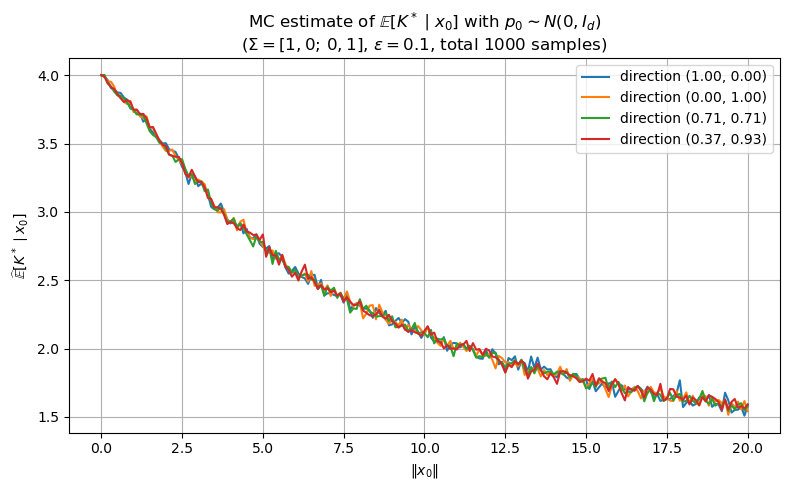

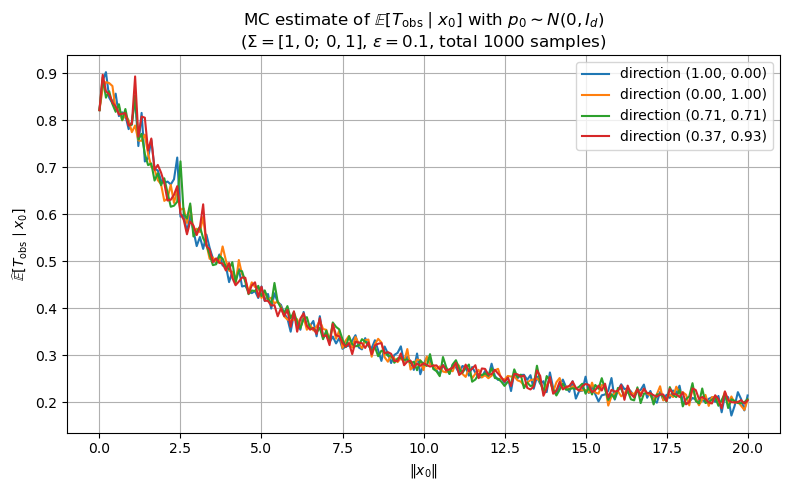

In [8]:
directions = [
    np.array([1.0, 0.0])/np.linalg.norm([1.0, 0.0]),
    np.array([0.0, 1.0])/np.linalg.norm([0.0, 1.0]),
    np.array([1.0, 1.0])/np.linalg.norm([1.0, 1.0]),
    np.array([1.0, 2.5])/np.linalg.norm([1.0, 2.5])
]

Sigma = np.eye(2)

# 1000 reps (2min) for one direction ; 10000 reps (20-21min) for one direction
plot_MC_estimate_K_and_Tobs(scale_vals, directions, Sigma, epsilon, n_rep=1000)

In [9]:
def plot_2d_gaussian_density_with_directions(
    Sigma,
    mu=None,
    directions=None,
    direction_labels=None,
    xlim=(-6, 6),
    ylim=(-6, 6),
    grid_size=400,
    arrow_length=5.0,
    n_contourf_levels=40,
    n_contour_levels=12,
    figsize=(8, 6),
    title=None,
    save_path=None
):
    """
    Plot the density of a 2D Gaussian N(mu, Sigma), together with selected
    unit direction vectors from the origin.

    Parameters
    ----------
    Sigma : np.ndarray, shape (2, 2)
        Covariance matrix.

    mu : np.ndarray, shape (2,), optional
        Mean vector. If None, uses np.array([0.0, 0.0]).

    directions : list[np.ndarray], optional
        List of direction vectors. They will be normalised automatically.

    direction_labels : list[str], optional
        Labels for the direction vectors.

    xlim, ylim : tuple
        Plot limits for x_1 and x_2.

    grid_size : int
        Number of grid points in each coordinate.

    arrow_length : float
        Length of the plotted direction arrows.

    n_contourf_levels : int
        Number of filled contour levels.

    n_contour_levels : int
        Number of contour line levels.

    figsize : tuple
        Figure size.

    title : str, optional
        Custom plot title.

    save_path : str, optional
        If provided, saves the figure to this path.

    Returns
    -------
    fig, ax
        Matplotlib figure and axis objects.
    """

    Sigma = np.asarray(Sigma, dtype=float)

    if Sigma.shape != (2, 2):
        raise ValueError("Sigma must be a 2 by 2 covariance matrix.")

    if mu is None:
        mu = np.array([0.0, 0.0])
    else:
        mu = np.asarray(mu, dtype=float)

    if mu.shape != (2,):
        raise ValueError("mu must have shape (2,).")

    # Normalise directions
    directions = [
        np.asarray(v, dtype=float) / np.linalg.norm(v)
        for v in directions
    ]

    if len(direction_labels) != len(directions):
        raise ValueError("direction_labels must have the same length as directions.")

    Sigma_inv = np.linalg.inv(Sigma)
    det_Sigma = np.linalg.det(Sigma)

    if det_Sigma <= 0:
        raise ValueError("Sigma must be positive definite.")

    # ------------------------------------------------------------
    # Grid for density plot
    # ------------------------------------------------------------
    x1 = np.linspace(xlim[0], xlim[1], grid_size)
    x2 = np.linspace(ylim[0], ylim[1], grid_size)

    X1, X2 = np.meshgrid(x1, x2)
    pos = np.dstack((X1, X2))

    # ------------------------------------------------------------
    # Multivariate Gaussian density
    # ------------------------------------------------------------
    diff = pos - mu

    quad_form = np.einsum(
        "...i,ij,...j->...",
        diff,
        Sigma_inv,
        diff
    )

    Z = (
        1.0 / (2.0 * np.pi * np.sqrt(det_Sigma))
        * np.exp(-0.5 * quad_form)
    )

    # ------------------------------------------------------------
    # Plot density
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    contour = ax.contourf(
        X1,
        X2,
        Z,
        levels=n_contourf_levels
    )

    fig.colorbar(contour, ax=ax, label="Density")

    ax.contour(
        X1,
        X2,
        Z,
        levels=n_contour_levels,
        linewidths=0.8
    )

    # Mean point
    ax.scatter(mu[0], mu[1], s=60, label="Mean")

    # ------------------------------------------------------------
    # Add direction vectors
    # ------------------------------------------------------------
    for v, label in zip(directions, direction_labels):
        ax.arrow(
            0,
            0,
            arrow_length * v[0],
            arrow_length * v[1],
            width=0.035,
            head_width=0.35,
            head_length=0.45,
            length_includes_head=True,
            label=label
        )

        ax.text(
            1.08 * arrow_length * v[0],
            1.08 * arrow_length * v[1],
            label,
            fontsize=11
        )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")

    if title is None:
        title = (
            r"Density plot of $N(0,\Sigma)$ with selected unit directions"
        )

    ax.set_title(title)

    ax.axis("equal")
    ax.legend(loc="upper left")
    ax.grid(False)

    fig.tight_layout()

    plt.show()

    return fig, ax

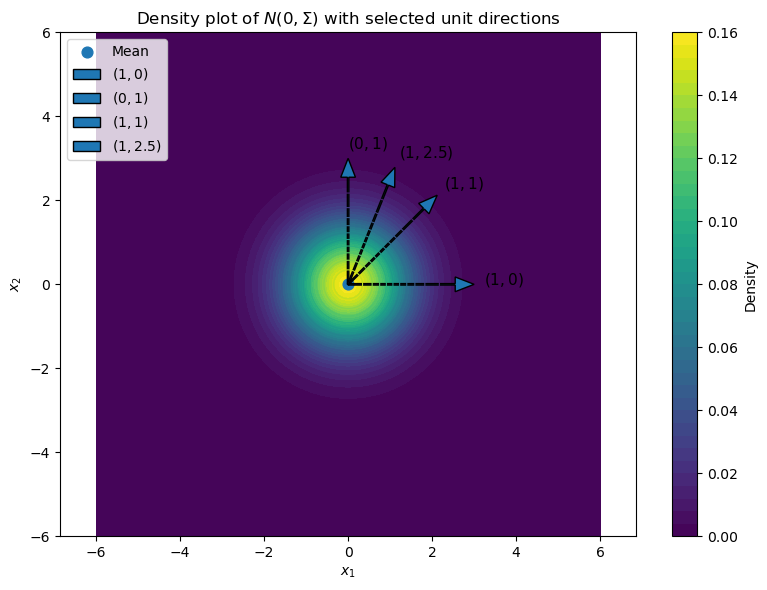

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density plot of $N(0,\\Sigma)$ with selected unit directions'}, xlabel='$x_1$', ylabel='$x_2$'>)

In [10]:
direction_labels = [
    r"$(1,0)$",
    r"$(0,1)$",
    r"$(1,1)$",
    r"$(1,2.5)$"
]

plot_2d_gaussian_density_with_directions(
    Sigma=Sigma,
    directions=directions,
    direction_labels=direction_labels,
    xlim=(-6, 6),
    ylim=(-6, 6),
    arrow_length=3.0
)

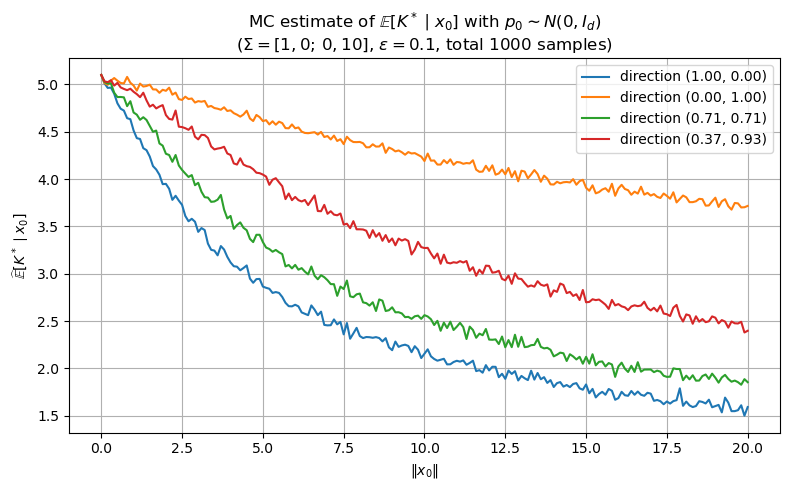

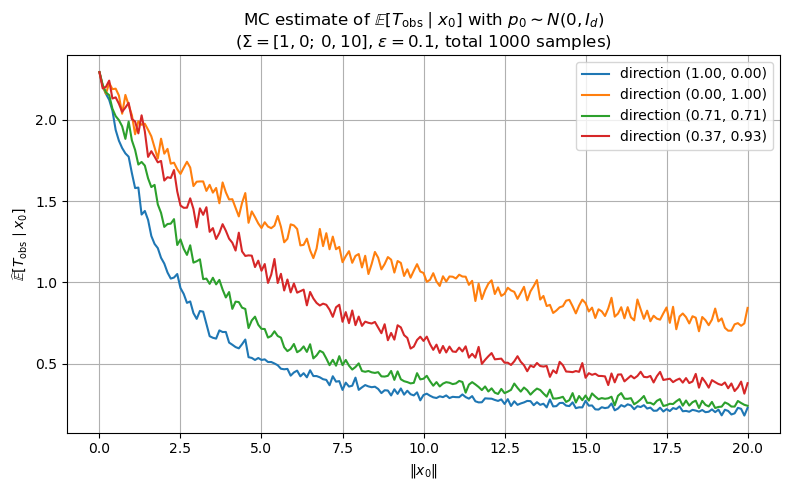

In [11]:
# 1000 reps (2min) for one direction ; 10000 reps (20-21min) for one direction
plot_MC_estimate_K_and_Tobs(scale_vals, directions, 
                            Sigma=np.array([[1.0, 0.0], [0.0, 10.0]]), epsilon=0.1, n_rep=1000)

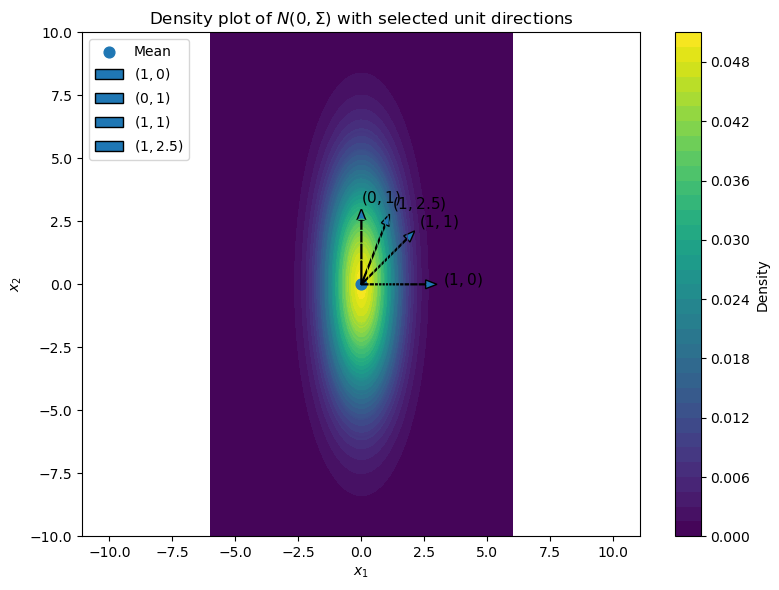

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density plot of $N(0,\\Sigma)$ with selected unit directions'}, xlabel='$x_1$', ylabel='$x_2$'>)

In [12]:
plot_2d_gaussian_density_with_directions(
    Sigma=np.array([[1.0, 0.0], [0.0, 10.0]]),
    directions=directions,
    direction_labels=direction_labels,
    xlim=(-6, 6),
    ylim=(-10, 10),
    arrow_length=3.0
)

#### Rotational invariance check

We check this by using the example that the target covariance matrix is $\Sigma = \frac{1}{9}\begin{pmatrix} 5 & -4\\ -4 & 5 \end{pmatrix}$.

In [56]:
def plot_MC_estimate_K_and_Tobs_multiple_cases(
    scale_vals,
    cases,
    epsilon=0.1,
    n_rep=1000
):
    """
    Plot MC estimates of E[K^* | x0] and E[T_obs | x0] for multiple
    covariance/direction cases.

    Parameters
    ----------
    scale_vals : array-like
        Values of ||x0||.

    cases : list[dict]
        Each case should have the form

            {
                "name": str,
                "Sigma": np.ndarray,
                "directions": list[np.ndarray],
                "direction_labels": list[str], optional
            }

    epsilon : float
        Step size.

    n_rep : int
        Number of Monte Carlo samples.
    """

    def matrix_to_latex(Sigma, decimals=3):
        Sigma = np.asarray(Sigma)
        rows = []
        for row in Sigma:
            row_str = ",".join(f"{v:.{decimals}g}" for v in row)
            rows.append(row_str)
        return r"\left[" + r";\, ".join(rows) + r"\right]"

    # ------------------------------------------------------------
    # Run all simulations first
    # ------------------------------------------------------------
    all_results = []

    for case in cases:
        case_name = case["name"]
        Sigma = case["Sigma"]
        directions = case["directions"]

        if "direction_labels" in case:
            direction_labels = case["direction_labels"]
        else:
            direction_labels = [
                "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"
                for direction in directions
            ]

        for direction, direction_label in zip(directions, direction_labels):
            EK_sim, T_obs_sim = EK_T_by_simulation_MultiD(
                scale_vals=scale_vals,
                direction=direction,
                Sigma=Sigma,
                epsilon=epsilon,
                n_rep=n_rep
            )

            all_results.append({
                "case_name": case_name,
                "Sigma": Sigma,
                "direction": direction,
                "direction_label": direction_label,
                "EK_sim": EK_sim,
                "T_obs_sim": T_obs_sim
            })

    # ------------------------------------------------------------
    # Figure 1: E[K^* | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(9, 5))

    for res in all_results:
        label = f"{res['case_name']}, direction {res['direction_label']}"

        plt.plot(
            scale_vals,
            res["EK_sim"],
            # marker="o",
            label=label
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figure 2: E[T_obs | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(9, 5))

    for res in all_results:
        label = f"{res['case_name']}, direction {res['direction_label']}"

        plt.plot(
            scale_vals,
            res["T_obs_sim"],
            # marker="o",
            label=label
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[T_{\mathrm{obs}}\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return all_results

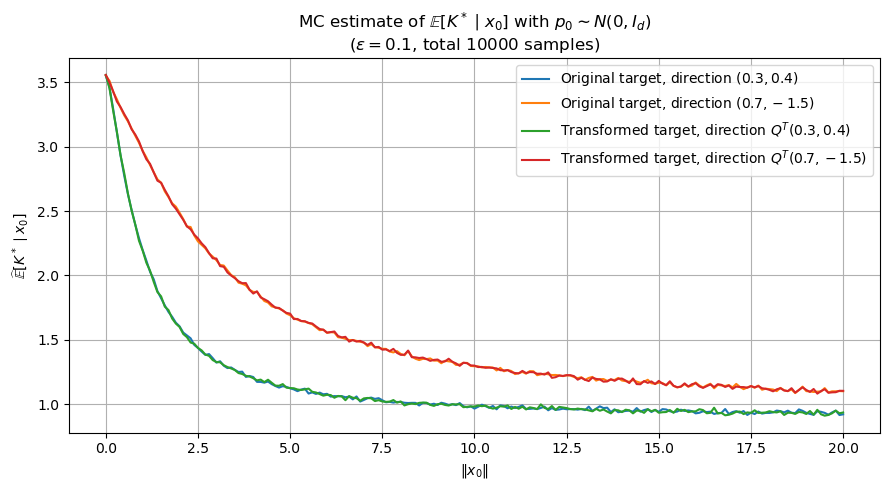

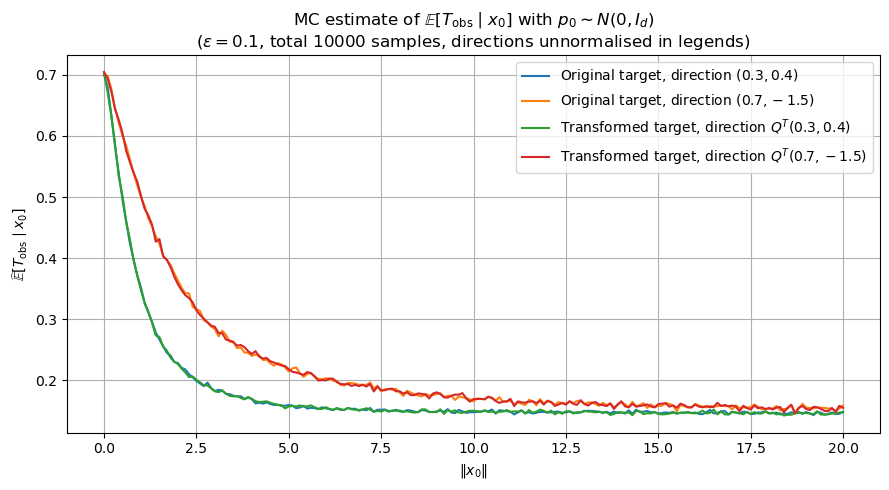

In [60]:
Sigma = 1/9 * np.array([[5.0, -4.0], [-4.0, 5.0]])
Sigma_inv = np.linalg.inv(Sigma)
eigvals, eigvecs = np.linalg.eigh(Sigma_inv)
Q = eigvecs
D = np.diag(eigvals)

directions_target = [
    np.array([0.3, 0.4])/np.linalg.norm([0.3, 0.4]),
    np.array([0.7, -1.5])/np.linalg.norm([0.7, -1.5])
]

directions_transformed = [Q.T @ v for v in directions_target]

cases = [
    {
        "name": r"Original target",
        "Sigma": Sigma,
        "directions": directions_target,
        "direction_labels": [
            r"$(0.3,0.4)$",
            r"$(0.7,-1.5)$"
        ]
    },
    {
        "name": r"Transformed target",
        "Sigma": np.linalg.inv(D),
        "directions": directions_transformed,
        "direction_labels": [
            r"$Q^T(0.3,0.4)$",
            r"$Q^T(0.7,-1.5)$"
        ]
    }
]

all_results = plot_MC_estimate_K_and_Tobs_multiple_cases(
    scale_vals=scale_vals,
    cases=cases,
    epsilon=0.1,
    n_rep=10000
)

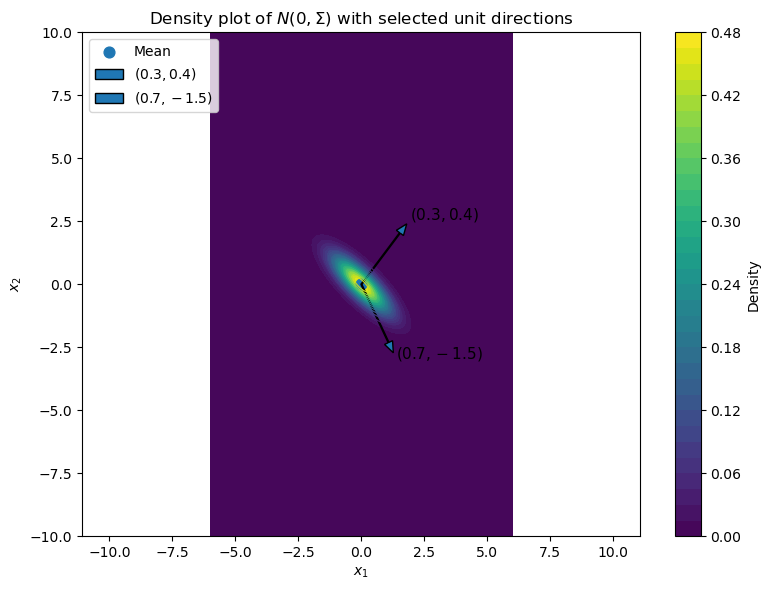

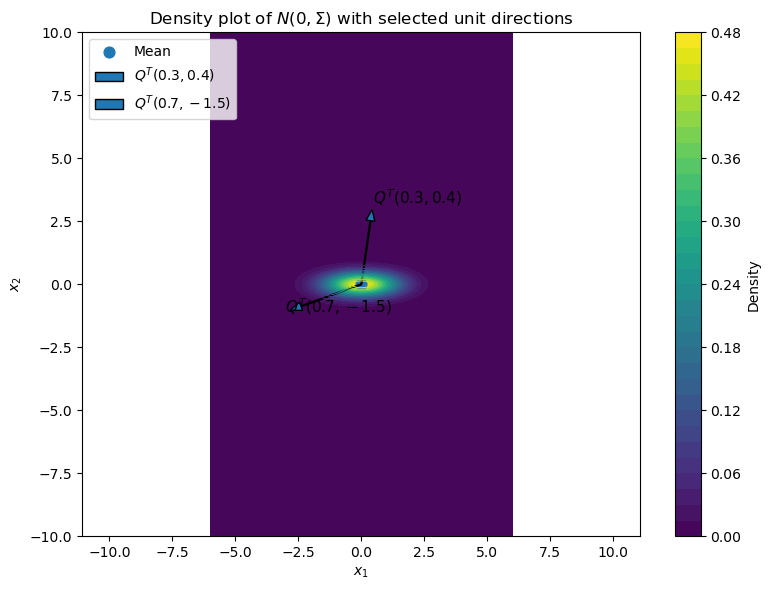

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density plot of $N(0,\\Sigma)$ with selected unit directions'}, xlabel='$x_1$', ylabel='$x_2$'>)

In [58]:
direction_target_labels = [
    r"$(0.3,0.4)$",
    r"$(0.7,-1.5)$"
]

direction_transformed_labels = [
    r"$Q^T(0.3,0.4)$",
    r"$Q^T(0.7,-1.5)$"
]


plot_2d_gaussian_density_with_directions(
    Sigma=Sigma,
    directions=directions_target,
    direction_labels=direction_target_labels,
    xlim=(-6, 6),
    ylim=(-10, 10),
    arrow_length=3.0
)

plot_2d_gaussian_density_with_directions(
    Sigma=np.linalg.inv(D),
    directions=directions_transformed,
    direction_labels=direction_transformed_labels,
    xlim=(-6, 6),
    ylim=(-10, 10),
    arrow_length=3.0
)

#### 3D Gaussian analysis

Cases for the covariance matrix interested:

1. Isotropic covariance matrix.

2. Non-isotropic, diagonal covariance matrix. Along with axis directions: $(1/d, 0, \cdots, 0)$, and other directions that diverges: $(1/d, 1/d, \cdots, 0)$ to $(1/d, 1/d, \cdots, 1/d)$.

3. Non-isotropic, and non-diagonal covariance matrix.

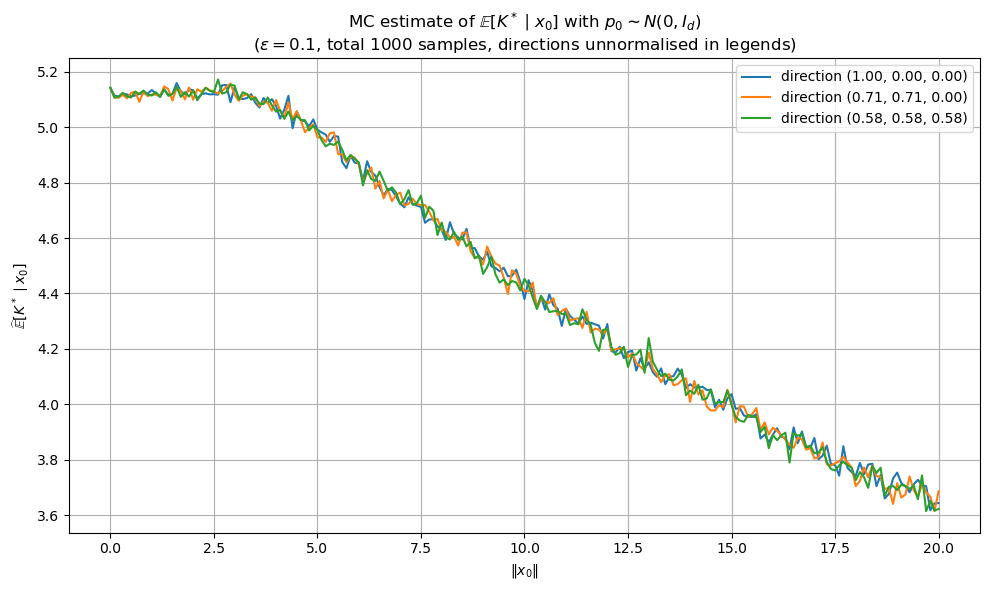

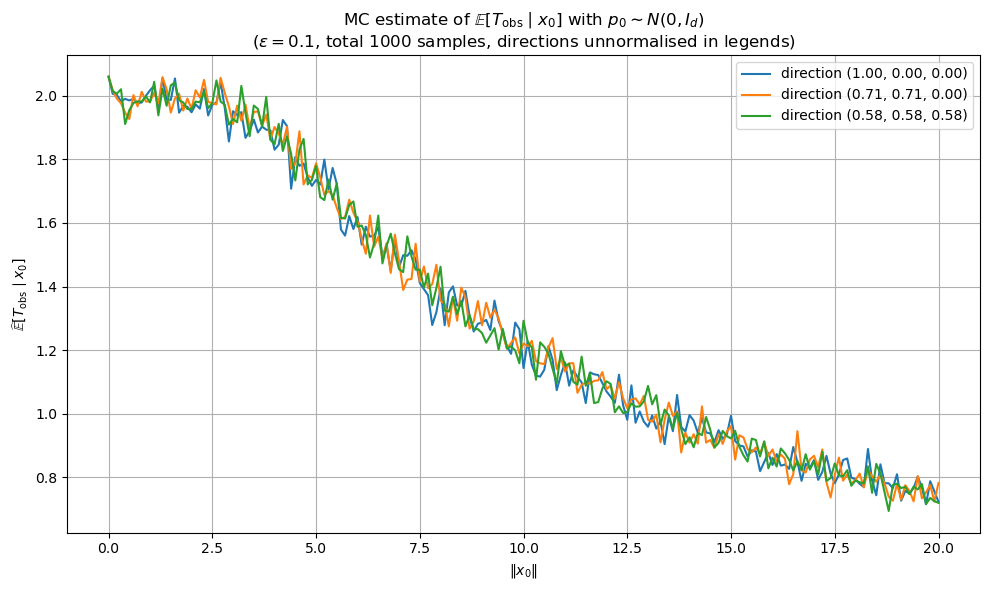

In [77]:
# Isotropic 3D covariance matrix

Sigma_3d = 5 * np.eye(3)

directions_3d = [
    np.array([1.0, 0.0, 0.0]),  # axis direction
    np.array([1.0, 1.0, 0.0]),  # 2-component divergence
    np.array([1.0, 1.0, 1.0])  # 3-component divergence
]

# Self-normalise the directions
directions_3d = [v / np.linalg.norm(v) for v in directions_3d]

plot_MC_estimate_K_and_Tobs(scale_vals, directions_3d, Sigma_3d, epsilon, n_rep=1000)

#### 5D Gaussian analysis

Cases for the covariance matrix interested:

1. Isotropic covariance matrix.

2. Non-isotropic, diagonal covariance matrix. Along with axis directions: $(1/d, 0, \cdots, 0)$, and other directions that diverges: $(1/d, 1/d, \cdots, 0)$ to $(1/d, 1/d, \cdots, 1/d)$.

3. Non-isotropic, and non-diagonal covariance matrix.

In [69]:
def plot_MC_estimate_K_and_Tobs(scale_vals, directions, Sigma, epsilon, n_rep):

    # Store results so we do not run the simulations twice
    results = []

    for direction in directions:
        EK_sim, T_obs_sim = EK_T_by_simulation_MultiD(
            scale_vals=scale_vals,
            direction=direction,
            Sigma=Sigma,
            epsilon=epsilon,
            n_rep=n_rep
        )

        direction_str = "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"

        results.append({
            "direction": direction,
            "direction_str": direction_str,
            "EK_sim": EK_sim,
            "T_obs_sim": T_obs_sim
        })

    # ------------------------------------------------------------
    # Figure 1: E[K^* | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for res in results:
        plt.plot(
            scale_vals,
            res["EK_sim"],
            label=f"direction {res['direction_str']}"
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figure 2: E[T_obs | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for res in results:
        plt.plot(
            scale_vals,
            res["T_obs_sim"],
            label=f"direction {res['direction_str']}"
        )

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[T_{\mathrm{obs}}\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

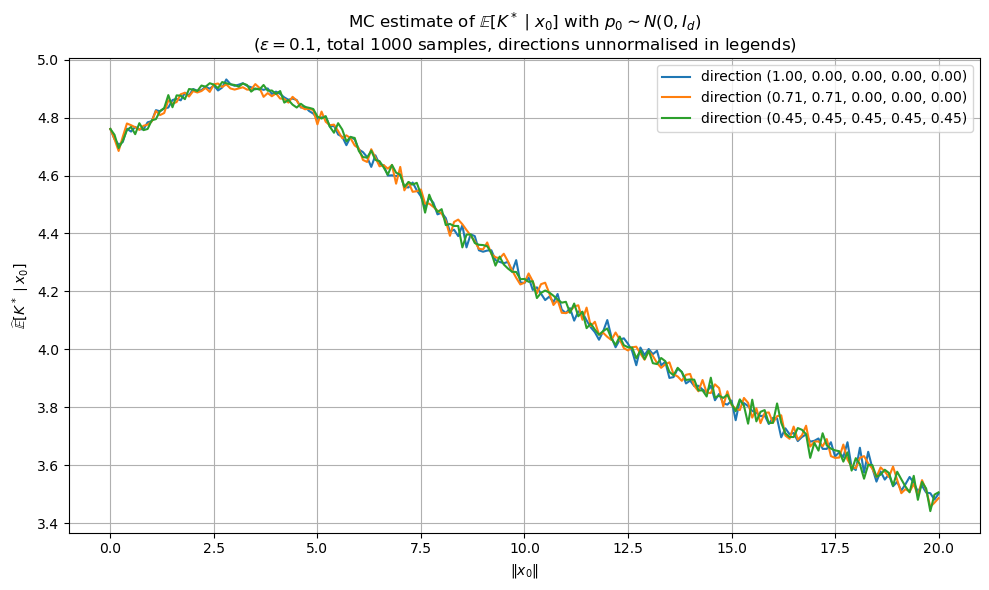

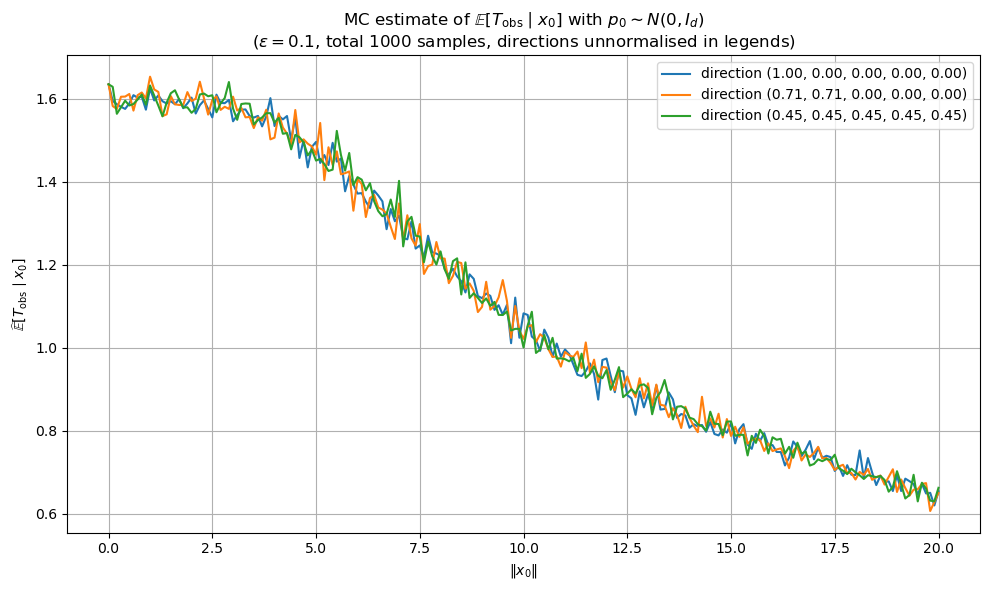

In [76]:
# Isotropic 5D covariance matrix

Sigma_5d = 3 * np.eye(5)

directions_5d = [
    np.array([1.0, 0.0, 0.0, 0.0, 0.0]),  # axis direction
    np.array([1.0, 1.0, 0.0, 0.0, 0.0]),  # 2-component divergence
    np.array([1.0, 1.0, 1.0, 1.0, 1.0])  # 5-component divergence
]

# Self-normalise the directions
directions_5d = [v / np.linalg.norm(v) for v in directions_5d]

plot_MC_estimate_K_and_Tobs(scale_vals, directions_5d, Sigma_5d, epsilon, n_rep=1000)

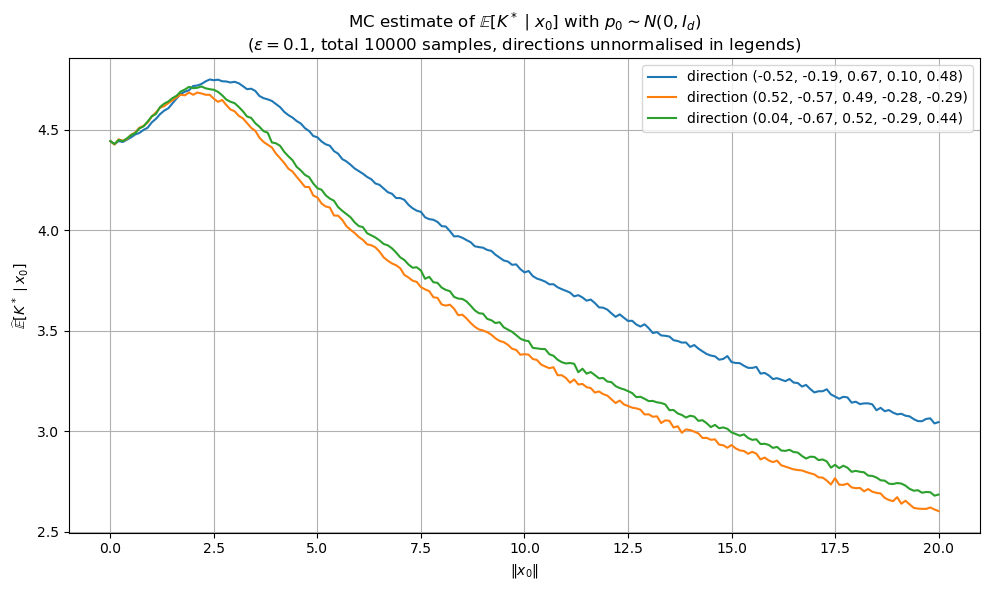

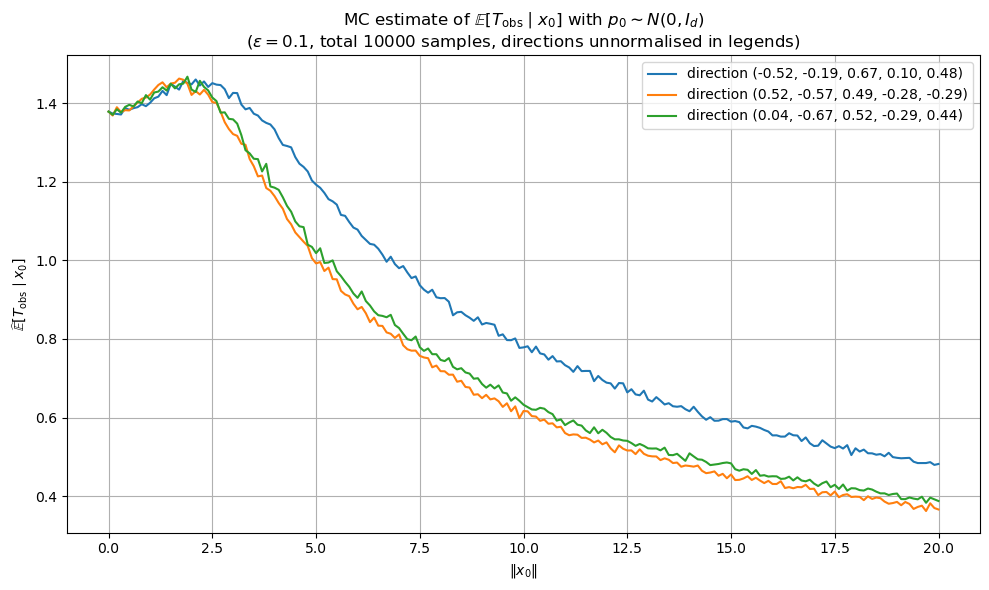

In [ ]:
# A random isotropic 5D covariance matrix with off-diagonal correlations

Sigma_5d = np.array([
    [2.00, 0.50, 0.30, 0.10, 0.20],
    [0.50, 1.50, 0.40, 0.20, 0.10],
    [0.30, 0.40, 3.00, 0.60, 0.30],
    [0.10, 0.20, 0.60, 2.50, 0.50],
    [0.20, 0.10, 0.30, 0.50, 1.80]
])


rng = np.random.default_rng(123)

# Some random directions on the 5D unit sphere
random_dirs = []

for _ in range(3):
    v = rng.normal(size=5)
    v = v / np.linalg.norm(v)
    random_dirs.append(v)

directions_5d = [
    random_dirs[0],
    random_dirs[1],
    random_dirs[2]
]

plot_MC_estimate_K_and_Tobs(scale_vals, directions_5d, Sigma_5d, epsilon, n_rep=10000)

#### 10D Gaussian example

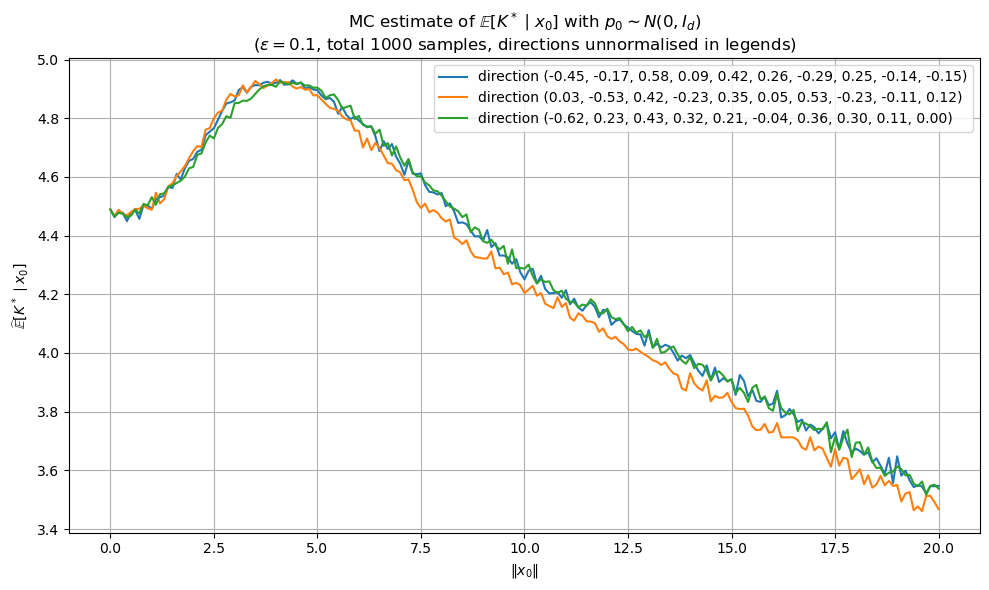

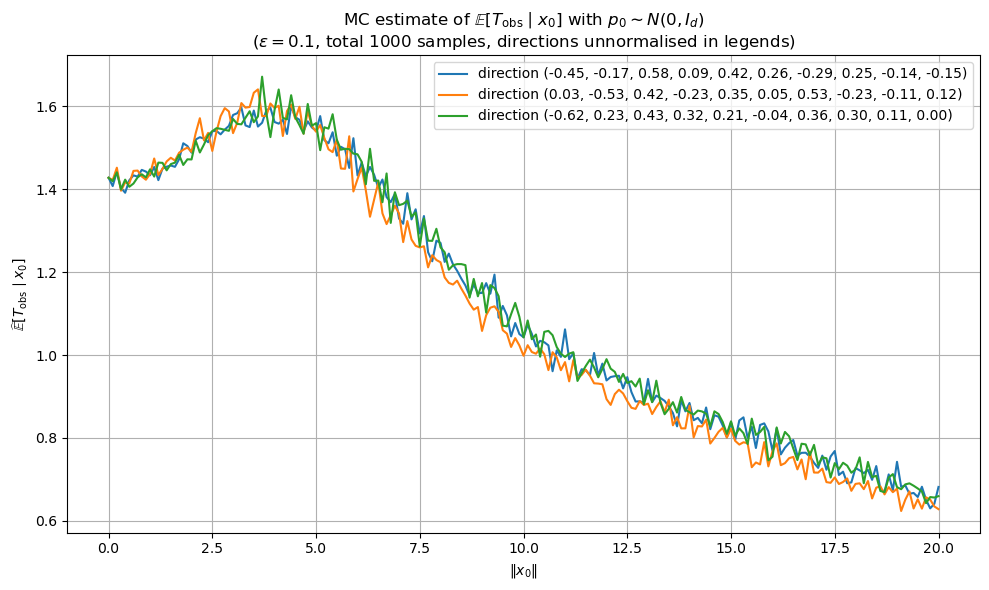

In [74]:
Sigma_10d = np.array([
    [2.00, 0.40, 0.30, 0.10, 0.20, 0.10, 0.00, 0.15, 0.05, 0.10],
    [0.40, 1.80, 0.35, 0.20, 0.10, 0.15, 0.05, 0.10, 0.00, 0.05],
    [0.30, 0.35, 3.00, 0.50, 0.25, 0.20, 0.10, 0.05, 0.15, 0.10],
    [0.10, 0.20, 0.50, 2.50, 0.45, 0.25, 0.15, 0.10, 0.05, 0.20],
    [0.20, 0.10, 0.25, 0.45, 2.20, 0.40, 0.20, 0.15, 0.10, 0.05],
    [0.10, 0.15, 0.20, 0.25, 0.40, 1.70, 0.35, 0.20, 0.10, 0.15],
    [0.00, 0.05, 0.10, 0.15, 0.20, 0.35, 2.80, 0.45, 0.25, 0.20],
    [0.15, 0.10, 0.05, 0.10, 0.15, 0.20, 0.45, 2.40, 0.40, 0.25],
    [0.05, 0.00, 0.15, 0.05, 0.10, 0.10, 0.25, 0.40, 1.90, 0.35],
    [0.10, 0.05, 0.10, 0.20, 0.05, 0.15, 0.20, 0.25, 0.35, 2.10]
])

rng = np.random.default_rng(123)

# Some random directions on the 5D unit sphere
random_dirs = []

for _ in range(3):
    v = rng.normal(size=10)
    v = v / np.linalg.norm(v)
    random_dirs.append(v)

directions_10d = [
    random_dirs[0],
    random_dirs[1],
    random_dirs[2]
]

plot_MC_estimate_K_and_Tobs(scale_vals, directions_10d, Sigma_10d, epsilon, n_rep=1000)

#### Even higher dimension simulations - isotropic

In [30]:
def plot_MC_estimate_K_and_Tobs(scale_vals, directions, sigma, d, epsilon, n_rep):

    # Store results so we do not run the simulations twice
    results = []

    
    for direction in directions:
        EK_sim, T_obs_sim = EK_T_by_simulation_MultiD(
            scale_vals=scale_vals,
            direction=direction,
            Sigma=sigma**2 * np.eye(d),  # isotropic covariance
            epsilon=epsilon,
            n_rep=n_rep
        )

        direction_str = "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"

        results.append({
            "direction": direction,
            "direction_str": direction_str,
            "EK_sim": EK_sim,
            "T_obs_sim": T_obs_sim
        })

    # ------------------------------------------------------------
    # Figure 1: E[K^* | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for res in results:
        plt.plot(
            scale_vals,
            res["EK_sim"]
        )

    plt.axvline(x=sigma * np.sqrt(d), color='red', linestyle='--', linewidth=1)

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    # plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figure 2: E[T_obs | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for res in results:
        plt.plot(
            scale_vals,
            res["T_obs_sim"]
        )
    
    plt.axvline(x=sigma * np.sqrt(d), color='red', linestyle='--', linewidth=1)

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[T_{\mathrm{obs}}\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    # plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

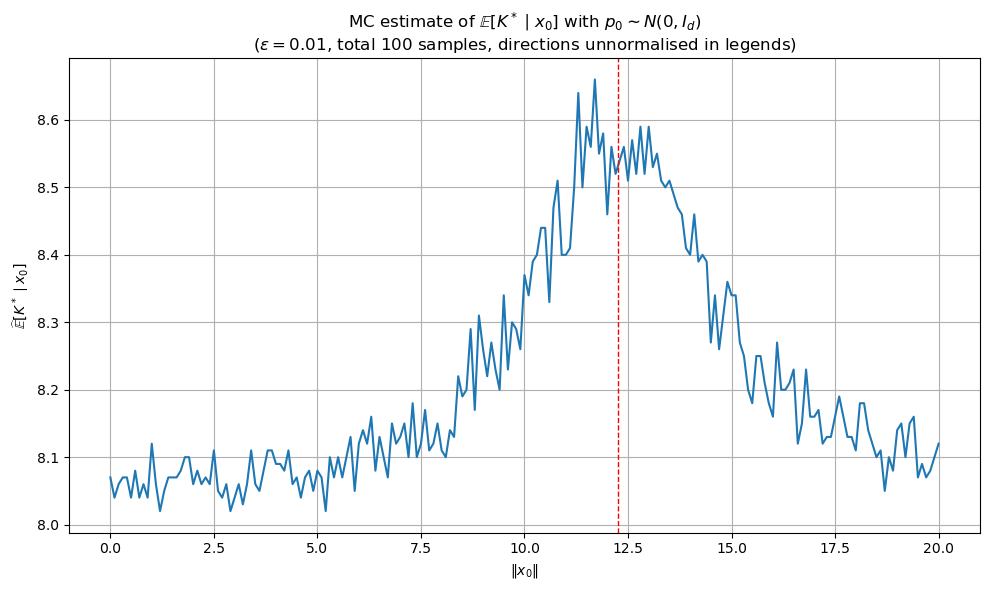

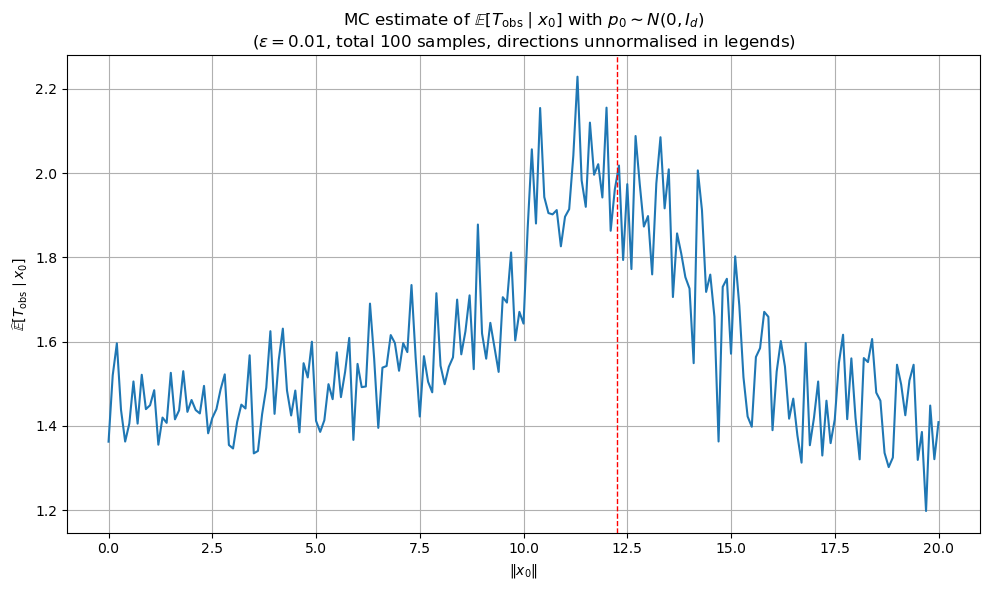

In [19]:
# Isotropic 50D covariance matrix

d = 50

sigma = np.sqrt(3.0)  # so the isotropic covariance matrix is 3 * I_d

directions_d = np.zeros(d)
directions_d[0] = 1.0  # axis direction

# Self-normalise the directions
directions_d = [directions_d / np.linalg.norm(directions_d)]

plot_MC_estimate_K_and_Tobs(scale_vals, directions_d, sigma, d, epsilon=0.01, n_rep=100)  # maybe a smaller stepsize (0.01) works better for high dimensions?

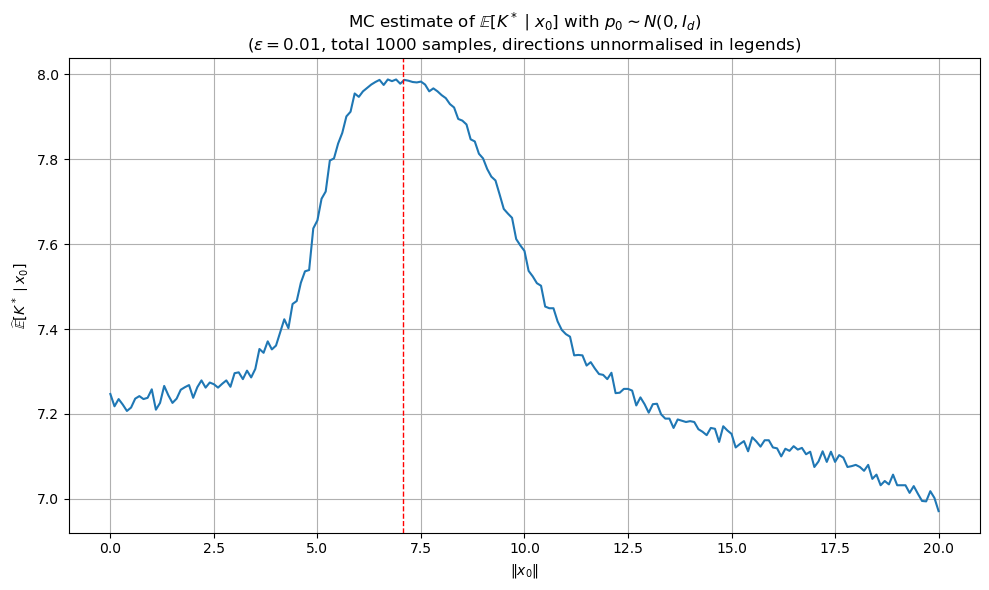

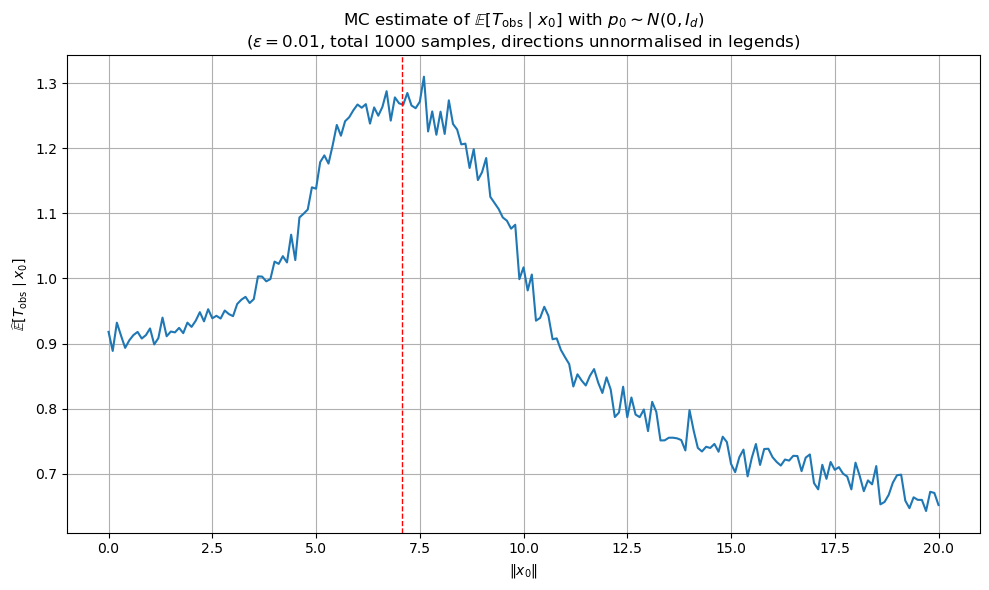

In [21]:
# Isotropic 50D covariance matrix

d = 50

sigma = 1.0

directions_d = np.zeros(d)
directions_d[0] = 1.0  # axis direction

# Self-normalise the directions
directions_d = [directions_d / np.linalg.norm(directions_d)]

plot_MC_estimate_K_and_Tobs(scale_vals, directions_d, sigma, d, epsilon=0.01, n_rep=1000)

#### Even higher dimension simulations - non-isotropic, diagonal

In [40]:
def plot_MC_estimate_K_and_Tobs_non_iso(scale_vals, directions, Sigma, epsilon, n_rep):

    # Store results so we do not run the simulations twice
    results = []

    
    for direction in directions:
        EK_sim, T_obs_sim = EK_T_by_simulation_MultiD(
            scale_vals=scale_vals,
            direction=direction,
            Sigma=Sigma,  # non-isotropic covariance, but diagonal
            epsilon=epsilon,
            n_rep=n_rep
        )

        # Compute the bump position, using small stepsize approximation
        A = np.linalg.inv(Sigma)
        num = np.trace(A).item()
        deno = direction @ (A @ A) @ direction
        bump_scale = np.sqrt(num / deno) if deno != 0 else np.inf

        direction_str = "(" + ", ".join(f"{d:.2f}" for d in direction) + ")"

        results.append({
            "direction": direction,
            "direction_str": direction_str,
            "EK_sim": EK_sim,
            "T_obs_sim": T_obs_sim,
            "bump_scale": bump_scale
        })


    # ------------------------------------------------------------
    # Figure 1: E[K^* | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for i, res in enumerate(results):
        plt.plot(
            scale_vals,
            res["EK_sim"],
            label=f"Direction {i+1}, bump scale around {res['bump_scale']:.2f}"
        )
        plt.axvline(x=res["bump_scale"], color='red', linestyle='--', linewidth=1)

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Figure 2: E[T_obs | x0]
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for i, res in enumerate(results):
        plt.plot(
            scale_vals,
            res["T_obs_sim"],
            label=f"Direction {i+1}, bump scale around {res['bump_scale']:.2f}"
        )
        plt.axvline(x=res["bump_scale"], color='red', linestyle='--', linewidth=1)

    plt.xlabel(r"$\|x_0\|$")
    plt.ylabel(r"$\widehat{\mathbb{E}}[T_{\mathrm{obs}}\mid x_0]$")
    plt.title(
        r"MC estimate of $\mathbb{E}[T_{\mathrm{obs}}\mid x_0]$ with $p_0\sim N(0,I_d)$"
        "\n"
        rf"($\epsilon={epsilon}$, total {n_rep} samples, directions unnormalised in legends)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

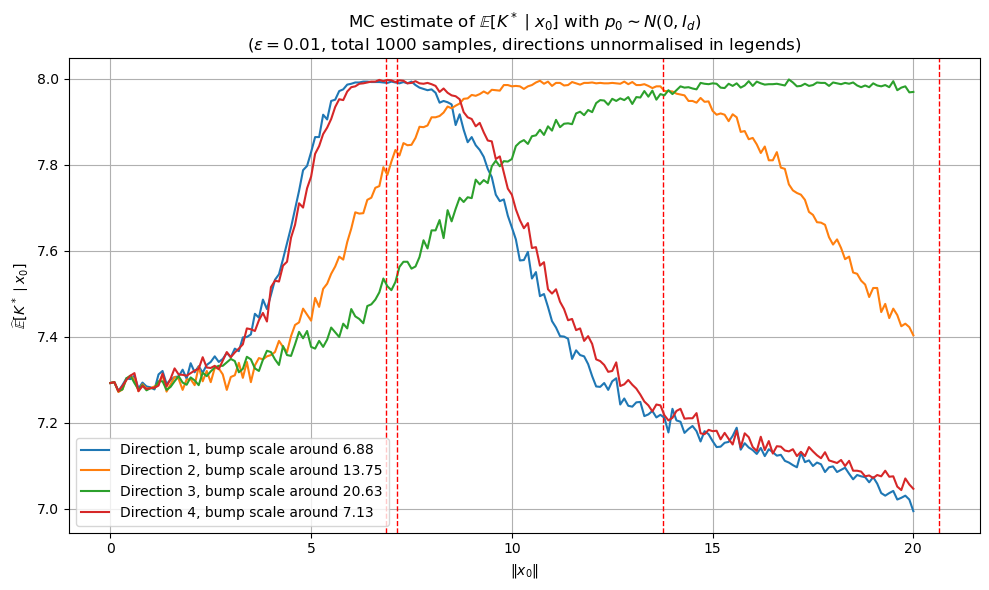

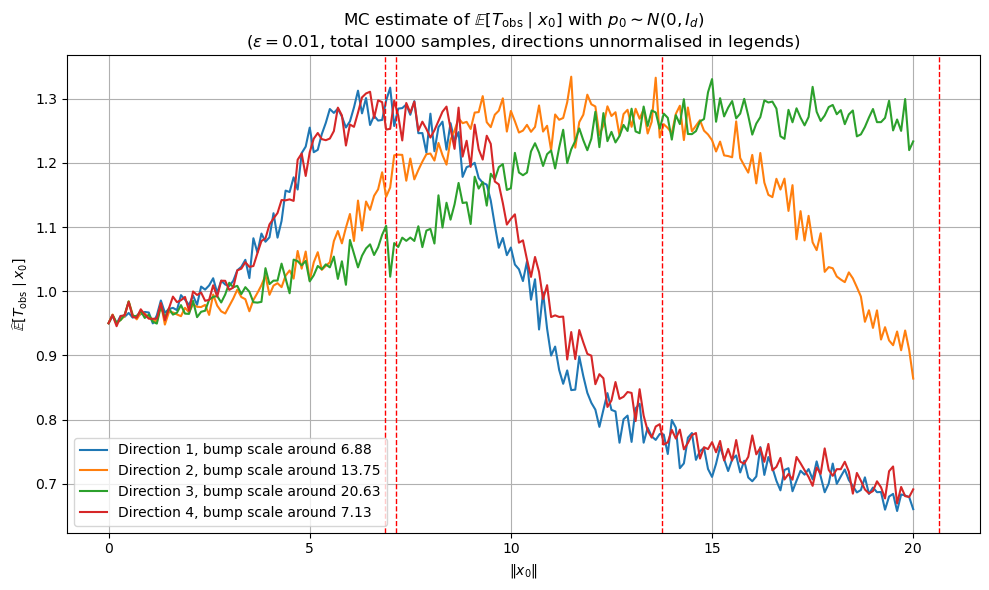

In [43]:
d = 50

Sigma = np.diag(np.array([1.0, 2.0, 3.0, 4.0, 5.0] + [1.0]*(d-5)))  # non-isotropic covariance matrix

e = np.eye(d)
directions_d = [
    e[0],                              # first coordinate direction
    e[1],                              # second coordinate direction
    e[2],                              # third coordinate direction
    np.ones(d),                  # diagonal direction in R^d
]

# Self-normalise the directions, around 7-8min for one direction with 100 repetitions, stepsize 0.01
directions_d = [direction / np.linalg.norm(direction) for direction in directions_d]

plot_MC_estimate_K_and_Tobs_non_iso(scale_vals, directions_d, Sigma, epsilon=0.01, n_rep=1000)

## Trajectory

In [13]:
def plot_one_NUTS_trajectory_multiD(
    x0,
    A=None,
    Sigma=None,
    epsilon=0.1,
    seed=0,
    max_depth=20,
    coords_to_plot=None,
    phase_coords=None,
):
    """
    Generate one exact-flow NUTS tree for a d-dimensional Gaussian target

        pi(x) = N(0, A^{-1}),

    where the Hamiltonian is

        H(x,p) = 1/2 x^T A x + 1/2 p^T p.

    The exact flow is

        x(t) = cos(t A^{1/2}) x0
               + A^{-1/2} sin(t A^{1/2}) p0,

        p(t) = - A^{1/2} sin(t A^{1/2}) x0
               + cos(t A^{1/2}) p0.

    This function plots:
        1. x_i(t) against t for selected coordinates,
        2. p_i(t) against t for selected coordinates,
        3. phase plots (x_i(t), p_i(t)),
        4. a 3D trajectory using two selected position coordinates and time.

    Parameters
    ----------
    x0 : array-like, shape (d,)
        Initial position.

    A : array-like, shape (d,d)
        Precision matrix A = Sigma^{-1}.

    Sigma : array-like, shape (d,d)
        Covariance matrix. If A is not supplied, A = inv(Sigma).

    epsilon : float
        Grid step size.

    seed : int
        Random seed.

    max_depth : int
        Maximum NUTS tree depth.

    coords_to_plot : list[int] or None
        Coordinates to plot. If None, plots the first min(d, 4) coordinates.

    phase_coords : list[int] or None
        Coordinates for phase plots. If None, uses coords_to_plot.

    Returns
    -------
    out : dict
        Output from the NUTS tree.

    t_vals : ndarray
        Grid times.

    x_vals : ndarray, shape (num_points, d)
        Position values on retained grid points.

    p_vals : ndarray, shape (num_points, d)
        Momentum values on retained grid points.
    """

    rng = np.random.default_rng(seed)

    x0 = np.asarray(x0, dtype=float)
    if Sigma is not None:
        Sigma = np.asarray(Sigma, dtype=float)
        A = np.linalg.inv(Sigma)
    else:
        A = np.asarray(A, dtype=float)

    d = len(x0)

    if coords_to_plot is None:
        coords_to_plot = list(range(min(d, 4)))

    if phase_coords is None:
        phase_coords = coords_to_plot

    # ------------------------------------------------------------
    # Construct high-dimensional exact-flow NUTS sampler
    # ------------------------------------------------------------
    sampler = ExactFlowNUTS_MultiD_Gaussian(
        A=A,
        epsilon=epsilon,
        rng=rng
    )

    # Sample p0 ~ N(0, I_d)
    p0 = rng.normal(0.0, 1.0, size=d)

    # Build one NUTS tree
    out = sampler.one_tree(
        x0=x0,
        p0=p0,
        max_depth=max_depth,
        return_sample=True
    )

    # Extract retained candidate indices
    C_indices = np.array(out["C_indices"], dtype=int)
    C_indices_sorted = np.sort(C_indices)

    # Convert grid indices to time
    t_vals = C_indices_sorted * epsilon

    # Evaluate exact-flow states
    x_vals = []
    p_vals = []

    for n in C_indices_sorted:
        x_n, p_n = sampler.state(n, x0, p0)
        x_vals.append(x_n)
        p_vals.append(p_n)

    x_vals = np.asarray(x_vals)
    p_vals = np.asarray(p_vals)

    # ------------------------------------------------------------
    # Print summary
    # ------------------------------------------------------------
    print(f"Dimension d = {d}")
    print(f"Initial x0 = {x0}")
    print(f"Initial p0 = {p0}")
    print(f"K* = {out['K_star']}")
    print(f"Final tree indices: [{out['left']}, {out['right']}]")

    if "T_obs" in out:
        print(
            f"The observed U-turn time T_obs = {out['T_obs']:.4f}, "
            f"at index {out['observed_uturn_index']} for the next doubling."
        )

    if "chosen_index" in out:
        print(f"Chosen sample index = {out['chosen_index']}")
        print(f"Chosen x = {out['x_sample']}")
        print(f"Chosen p = {out['p_sample']}")

    # ------------------------------------------------------------
    # Plot x_i(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(9, 5))

    for j in coords_to_plot:
        plt.plot(
            t_vals,
            x_vals[:, j],
            marker="o",
            label=rf"$x_{j+1}(t)$"
        )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel(r"$t=n\epsilon$")
    plt.ylabel(r"$x_i(t)$")
    plt.title("Exact-flow NUTS trajectory: position coordinates against time")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot p_i(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(9, 5))

    for j in coords_to_plot:
        plt.plot(
            t_vals,
            p_vals[:, j],
            marker="o",
            label=rf"$p_{j+1}(t)$"
        )

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel(r"$t=n\epsilon$")
    plt.ylabel(r"$p_i(t)$")
    plt.title("Exact-flow NUTS trajectory: momentum coordinates against time")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Phase plots: x_i(t) against p_i(t)
    # ------------------------------------------------------------
    for j in phase_coords:
        plt.figure(figsize=(6, 6))

        plt.plot(
            x_vals[:, j],
            p_vals[:, j],
            marker="o",
            label=rf"coordinate {j+1}"
        )

        plt.scatter(
            [x0[j]],
            [p0[j]],
            s=80,
            color="red",
            label="initial state"
        )

        if "x_sample" in out and "p_sample" in out:
            plt.scatter(
                [out["x_sample"][j]],
                [out["p_sample"][j]],
                s=80,
                color="orange",
                label="chosen sample"
            )

        plt.xlabel(rf"$x_{j+1}(t)$")
        plt.ylabel(rf"$p_{j+1}(t)$")
        plt.title(rf"Phase trajectory: $(x_{j+1}(t),p_{j+1}(t))$")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 3D plot: use first two plotted position coordinates and time
    # ------------------------------------------------------------
    if d >= 2:
        j1, j2 = coords_to_plot[0], coords_to_plot[1]

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot(
            x_vals[:, j1],
            x_vals[:, j2],
            t_vals,
            marker="o",
            label="NUTS retained states"
        )

        ax.scatter(
            [x0[j1]],
            [x0[j2]],
            [0.0],
            s=80,
            color="red",
            label="initial state"
        )

        if "x_sample" in out and "chosen_index" in out:
            ax.scatter(
                [out["x_sample"][j1]],
                [out["x_sample"][j2]],
                [out["chosen_index"] * epsilon],
                s=80,
                color="orange",
                label="chosen sample"
            )

        ax.set_xlabel(rf"$x_{j1+1}(t)$")
        ax.set_ylabel(rf"$x_{j2+1}(t)$")
        ax.set_zlabel(r"$t=n\epsilon$")
        ax.set_title(
            rf"Exact-flow NUTS trajectory in 3D: "
            rf"$(x_{j1+1}(t),x_{j2+1}(t),t)$"
        )
        ax.legend()
        plt.tight_layout()
        plt.show()

    return out, t_vals, x_vals, p_vals

Dimension d = 2
Initial x0 = [1. 1.]
Initial p0 = [0.34558419 0.82161814]
K* = 3
Final tree indices: [-3, 4]
The observed U-turn time T_obs = 0.5000, at index 5 for the next doubling.
Chosen sample index = -1
Chosen x = [0.96050331 0.91297922]
Chosen p = [0.44369113 0.91734689]


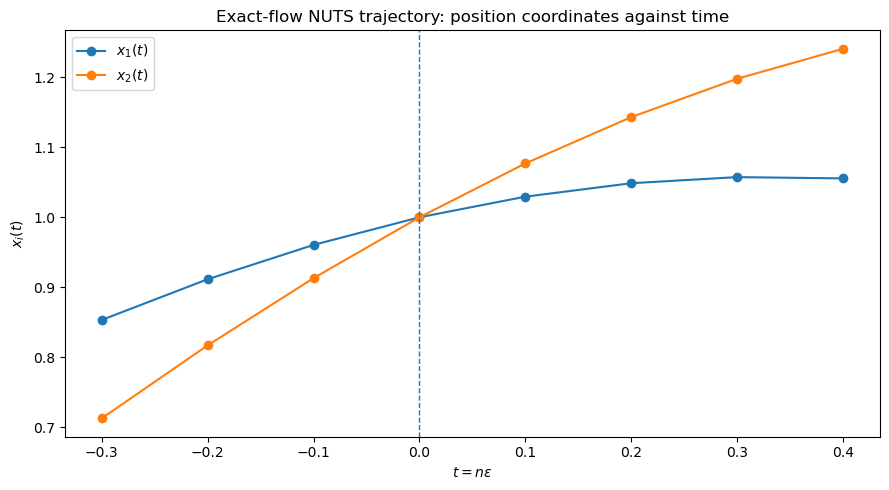

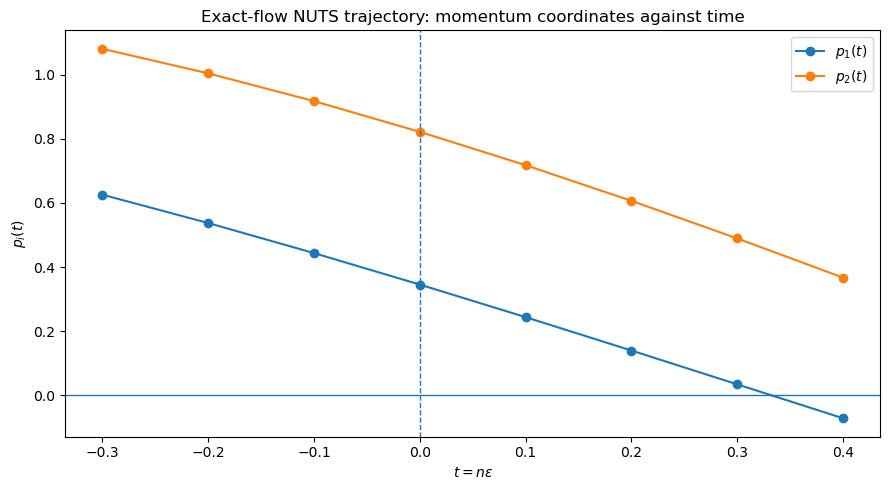

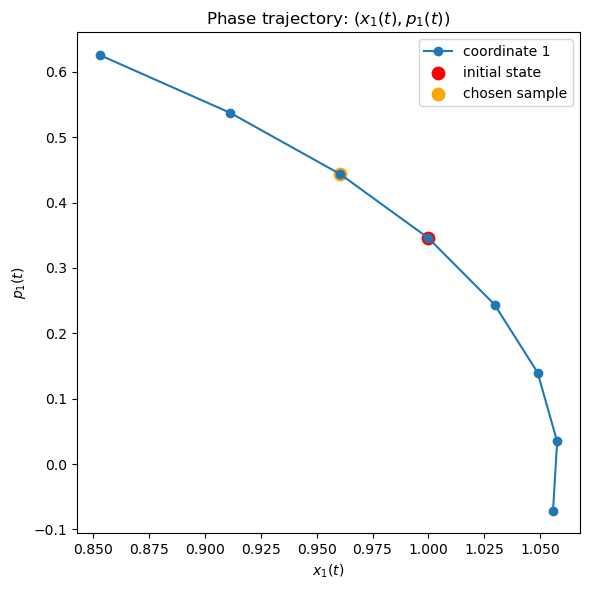

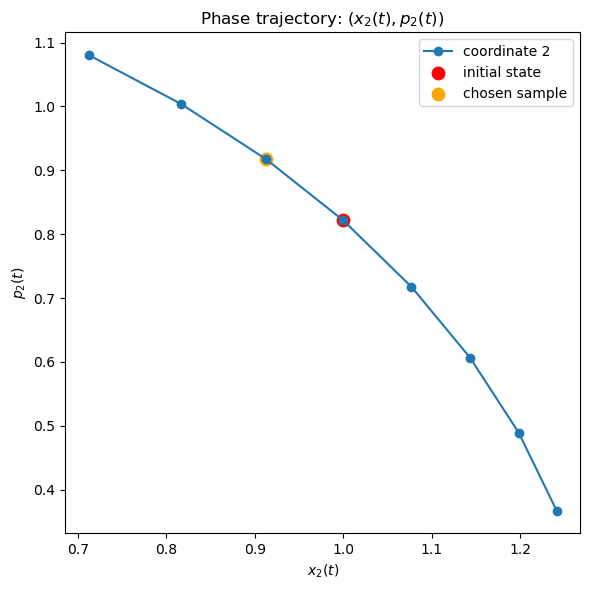

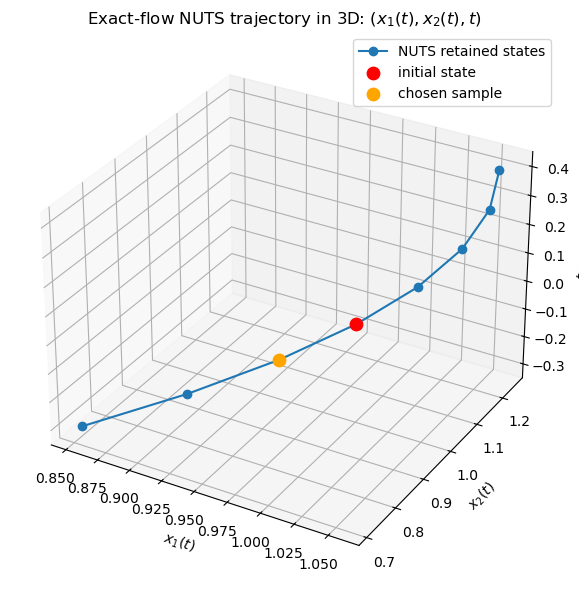

In [14]:
out, t_vals, x_vals, p_vals = plot_one_NUTS_trajectory_multiD(
    x0=np.array([1.0, 1.0]),
    A=None,
    Sigma=Sigma,
    epsilon=0.1,
    seed=1,
    max_depth=20
)

# Bump investigation

Example momentum decomposition for d=5
p0 = [-0.6156  0.1394  1.5199  1.6012  0.0617  0.4978 -0.3832  0.7968  2.0872
  1.6737]
z = u^T p0 = -0.6156
||w|| = 3.6172
||p0|| = 3.6692
cos angle(x0,p0) for x0 parallel to u = -0.1678
angle in degrees = 99.66


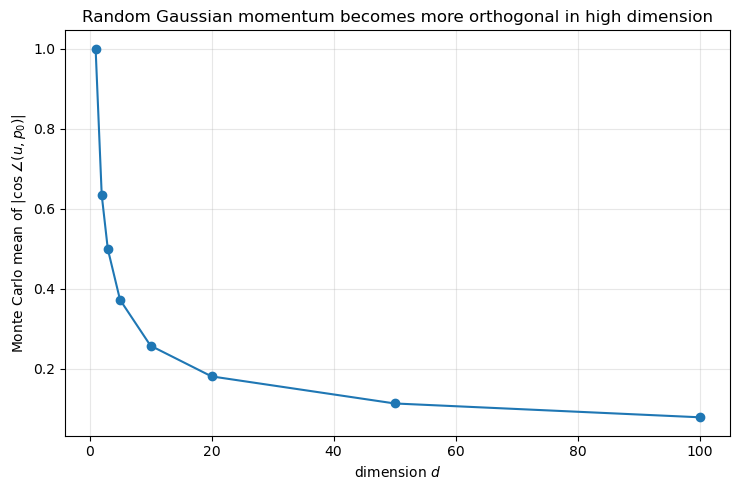

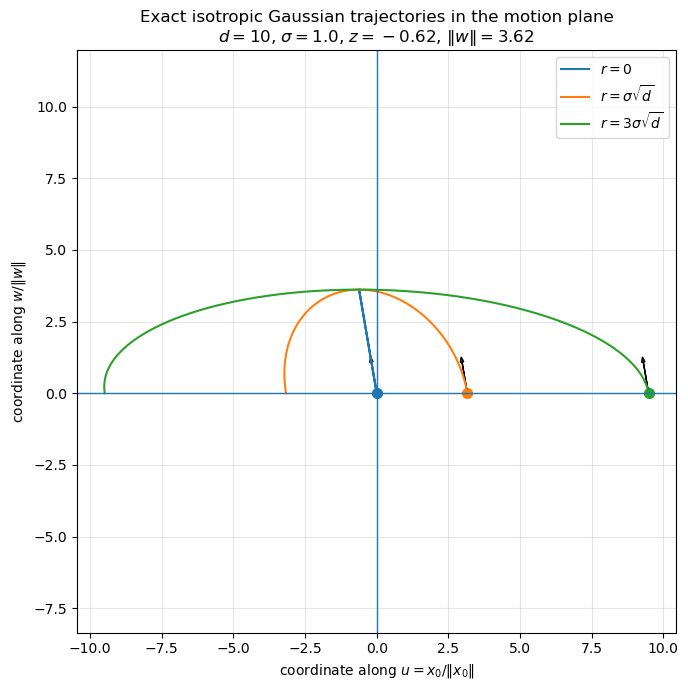

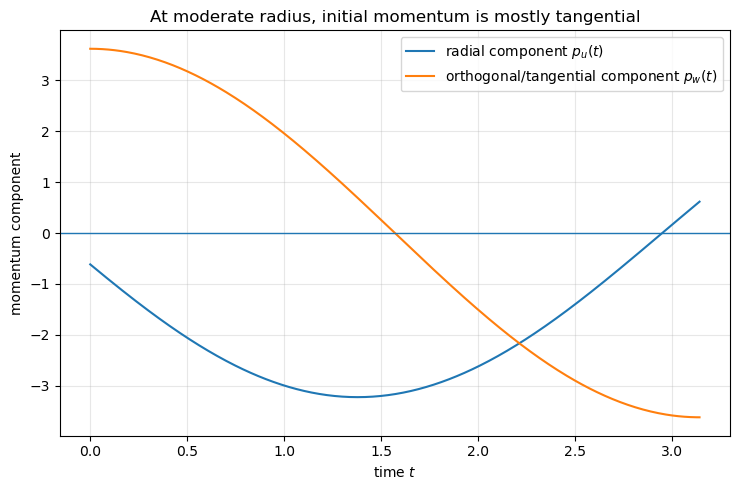

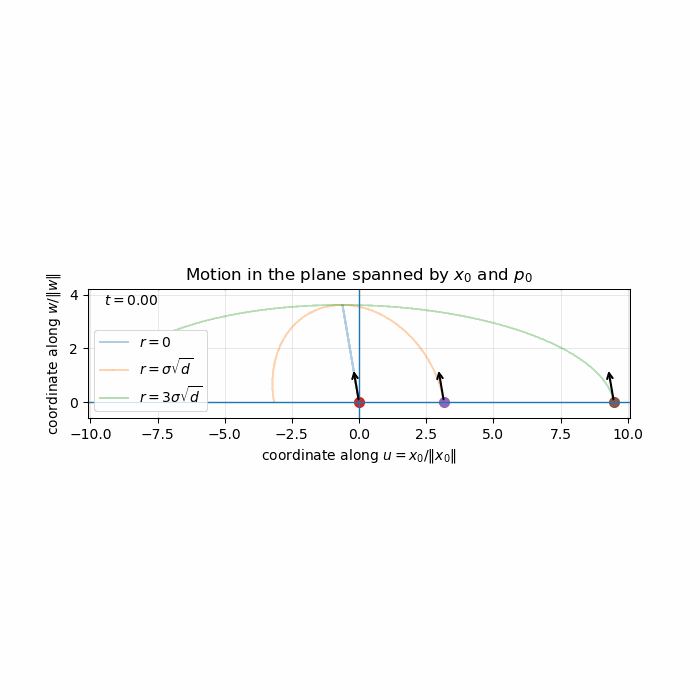

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
from pathlib import Path

outdir = Path("D:\\University documents\\PhD\\NUTS\\NUTS Bump")
outdir.mkdir(parents=True, exist_ok=True)


def plane_coordinates_for_isotropic_flow(r, z, wnorm, sigma, t_grid):
    """
    Work in the 2D basis (u, w/||w||), where

        x0 = r u,
        p0 = z u + w,
        w perpendicular to u.

    Then

        x_1(t) = r cos(t/sigma) + sigma z sin(t/sigma),
        x_2(t) = sigma ||w|| sin(t/sigma).

    The momentum coordinates are

        p_1(t) = z cos(t/sigma) - (r/sigma) sin(t/sigma),
        p_2(t) = ||w|| cos(t/sigma).
    """

    c = np.cos(t_grid / sigma)
    s = np.sin(t_grid / sigma)

    x1 = r * c + sigma * z * s
    x2 = sigma * wnorm * s

    p1 = z * c - (r / sigma) * s
    p2 = wnorm * c

    X = np.column_stack([x1, x2])
    P = np.column_stack([p1, p2])

    return X, P


def momentum_decomposition(d=5):
    """
    Choose u=e_1 and sample p0~N(0,I_d).
    Decompose p0 = z u + w.
    """

    u = np.zeros(d)
    u[0] = 1.0

    p0 = np.random.normal(size=d)

    z = float(np.dot(u, p0))
    w = p0 - z * u

    wnorm = float(np.linalg.norm(w))
    pnorm = float(np.linalg.norm(p0))

    cos_angle = z / pnorm

    return u, p0, z, wnorm, pnorm, cos_angle


def simulate_mean_abs_cos(d_values, n_rep=10000):
    """
    For fixed u=e_1, simulate

        |cos angle(u,p0)| = |p0_1| / ||p0||

    for p0~N(0,I_d).
    """

    means = []

    for d in d_values:
        P = np.random.normal(size=(n_rep, d))
        cos_vals = P[:, 0] / np.linalg.norm(P, axis=1)
        means.append(np.mean(np.abs(cos_vals)))

    return np.array(means)


# ------------------------------------------------------------
# Example setup
# ------------------------------------------------------------
d = 10
sigma = 1.0

u, p0, z, wnorm, pnorm, cos_angle = momentum_decomposition(d=d)

print("Example momentum decomposition for d=5")
print("p0 =", np.round(p0, 4))
print("z = u^T p0 =", round(z, 4))
print("||w|| =", round(wnorm, 4))
print("||p0|| =", round(pnorm, 4))
print("cos angle(x0,p0) for x0 parallel to u =", round(cos_angle, 4))
print("angle in degrees =", round(np.degrees(np.arccos(np.clip(cos_angle, -1, 1))), 2))


# ------------------------------------------------------------
# Figure 1: high-dimensional orthogonality
# ------------------------------------------------------------
d_values = np.array([1, 2, 3, 5, 10, 20, 50, 100])
mean_abs_cos = simulate_mean_abs_cos(d_values, n_rep=10000)

plt.figure(figsize=(7.5, 5))
plt.plot(d_values, mean_abs_cos, marker="o")
plt.xlabel(r"dimension $d$")
plt.ylabel(r"Monte Carlo mean of $|\cos\angle(u,p_0)|$")
plt.title(r"Random Gaussian momentum becomes more orthogonal in high dimension")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(outdir / "mean_abs_cos_vs_dimension.png", dpi=180, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 2: projected trajectories in the motion plane
# ------------------------------------------------------------
t_grid = np.linspace(0, np.pi * sigma, 400)

r_values = [
    0.0,
    sigma * np.sqrt(d),
    3.0 * sigma * np.sqrt(d),
]

r_labels = [
    r"$r=0$",
    r"$r=\sigma\sqrt{d}$",
    r"$r=3\sigma\sqrt{d}$",
]

plt.figure(figsize=(7, 7))

for r, lab in zip(r_values, r_labels):
    X, P = plane_coordinates_for_isotropic_flow(r, z, wnorm, sigma, t_grid)

    plt.plot(X[:, 0], X[:, 1], label=lab)
    plt.scatter([X[0, 0]], [X[0, 1]], s=50)

    # Initial momentum arrow
    p_start = P[0]
    scale = 0.35

    plt.arrow(
        X[0, 0],
        X[0, 1],
        scale * p_start[0],
        scale * p_start[1],
        head_width=0.12,
        length_includes_head=True,
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel(r"coordinate along $u=x_0/\|x_0\|$")
plt.ylabel(r"coordinate along $w/\|w\|$")
plt.title(
    "Exact isotropic Gaussian trajectories in the motion plane\n"
    + rf"$d={d}$, $\sigma={sigma}$, $z={z:.2f}$, $\|w\|={wnorm:.2f}$"
)
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(outdir / "projected_isotropic_trajectories.png", dpi=180, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 3: momentum components at moderate radius
# ------------------------------------------------------------
r = sigma * np.sqrt(d)

X, P = plane_coordinates_for_isotropic_flow(r, z, wnorm, sigma, t_grid)

plt.figure(figsize=(7.5, 5))
plt.plot(t_grid, P[:, 0], label=r"radial component $p_u(t)$")
plt.plot(t_grid, P[:, 1], label=r"orthogonal/tangential component $p_w(t)$")
plt.axhline(0, linewidth=1)

plt.xlabel(r"time $t$")
plt.ylabel("momentum component")
plt.title(r"At moderate radius, initial momentum is mostly tangential")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(outdir / "momentum_components_moderate_radius.png", dpi=180, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Animation: motion in the 2D plane spanned by x0 and p0
# ------------------------------------------------------------
frames = 100
t_anim = np.linspace(0, np.pi * sigma, frames)

traj_data = []

for r, lab in zip(r_values, r_labels):
    X, P = plane_coordinates_for_isotropic_flow(r, z, wnorm, sigma, t_anim)
    traj_data.append((X, P, lab))

all_points = np.vstack([item[0] for item in traj_data])

xmin, xmax = all_points[:, 0].min(), all_points[:, 0].max()
ymin, ymax = all_points[:, 1].min(), all_points[:, 1].max()
margin = 0.6

fig, ax = plt.subplots(figsize=(7, 7))

for X, P, lab in traj_data:
    ax.plot(X[:, 0], X[:, 1], alpha=0.35, label=lab)
    ax.scatter([X[0, 0]], [X[0, 1]], s=40)

moving_points = []
momentum_arrows = []

for X, P, lab in traj_data:
    point, = ax.plot([], [], marker="o", markersize=7)
    moving_points.append(point)

    arrow = ax.annotate(
        "",
        xy=(0, 0),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", lw=1.5),
    )

    momentum_arrows.append(arrow)

time_text = ax.text(0.03, 0.96, "", transform=ax.transAxes, va="top")

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlim(xmin - margin, xmax + margin)
ax.set_ylim(ymin - margin, ymax + margin)

ax.set_xlabel(r"coordinate along $u=x_0/\|x_0\|$")
ax.set_ylabel(r"coordinate along $w/\|w\|$")
ax.set_title(r"Motion in the plane spanned by $x_0$ and $p_0$")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box")


def init():
    for point in moving_points:
        point.set_data([], [])

    time_text.set_text("")

    return moving_points + momentum_arrows + [time_text]


def update(frame):
    arrow_scale = 0.35

    for j, (X, P, lab) in enumerate(traj_data):
        x = X[frame]
        p = P[frame]

        moving_points[j].set_data([x[0]], [x[1]])

        momentum_arrows[j].xy = (
            x[0] + arrow_scale * p[0],
            x[1] + arrow_scale * p[1],
        )

        momentum_arrows[j].set_position((x[0], x[1]))

    time_text.set_text(rf"$t={t_anim[frame]:.2f}$")

    return moving_points + momentum_arrows + [time_text]


anim = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=70,
    blit=False,
)

gif_path = outdir / "isotropic_motion_plane_animation.gif"
anim.save(gif_path, writer=PillowWriter(fps=14))

plt.close(fig)

display(Image(filename=str(gif_path)))